# 🔥🔫🗡️ Multi-Object Detection with YOLOv11: Fire, Gun & Knife Detection

<div style="background-color: #ffebcd; border-left: 5px solid #ff6b35; padding: 15px; border-radius: 5px;">
    <h2 style="color: #ff6b35; margin-top: 0;">🎯 Project Overview</h2>
    <p><strong>Objective:</strong> Train a unified YOLOv11 model to detect three critical objects: Fire, Guns, and Knives</p>
    <p><strong>Datasets Used:</strong></p>
    <ul>
        <li>🔥 <strong>FlameVision:</strong> Fire detection dataset (XML annotations converted to YOLO format)</li>
        <li>🔫 <strong>Weapon Detection:</strong> Multiple weapon types (mapped to Gun/Knife classes)</li>
        <li>🔪 <strong>Guns & Knives CCTV:</strong> CCTV-based weapon detection</li>
        <li>💨 <strong>Smoke & Fire Detection:</strong> Fire detection (ignoring smoke class)</li>
    </ul>
    <p><strong>Final Classes:</strong> Fire (0), Gun (1), Knife (2)</p>
</div>

## 📊 Class Mapping Strategy

**Original Weapon Classes → Final Classes:**
- `Automatic Rifle, Bazooka, Grenade Launcher, Handgun, Shotgun, SMG, Sniper` → **Gun (1)**
- `Knife` → **Knife (2)**
- `Sword` → **Knife (2)**
- `Fire` → **Fire (0)**
- `Smoke` → **Ignored**

---

## 📦 1. Install Required Libraries

First, let's install all the necessary dependencies for our multi-object detection project.

In [ ]:
# # Install required libraries
# !pip install ultralytics -q
# !pip install kagglehub -q

# print("✅ All libraries installed successfully!")

In [24]:
!pip uninstall -y tensorboard protobuf ultralytics torch torchvision torchaudio > /dev/null

# Install compatible stack
!pip install numpy==1.25.2 matplotlib==3.7.2 opencv-python==4.8.1.78 --quiet
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121 --quiet
!pip install ultralytics==8.3.0 --quiet

# Optional: Install TensorBoard safely (patched)
!pip install tensorboard==2.15.1 protobuf==4.25.3 --quiet


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
easyocr 1.7.2 requires opencv-python-headless, which is not installed.
ERROR: Cannot install protobuf==4.25.3 and tensorboard==2.15.1 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [1]:
# Step 1: Force uninstall conflicting packages
!pip uninstall -y numpy matplotlib opencv-python opencv-python-headless opencv-contrib-python ultralytics torch torchvision torchaudio tensorboard

# Step 2: Install stable NumPy <2
!pip install numpy==1.25.2

# Step 3: Reinstall Matplotlib and OpenCV compatible with NumPy 1.x
!pip install matplotlib==3.7.2
!pip install opencv-python==4.8.1.78

# Step 4: Install PyTorch after NumPy
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121

# Step 5: Install stable TensorBoard
!pip install tensorboard==2.13.0

# Step 6: Install Ultralytics YOLO after all dependencies
!pip install ultralytics==8.3.0

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: matplotlib 3.7.2
Uninstalling matplotlib-3.7.2:
  Successfully uninstalled matplotlib-3.7.2
Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: opencv-python-headless 4.12.0.88
Uninstalling opencv-python-headless-4.12.0.88:
  Successfully uninstalled opencv-python-headless-4.12.0.88
Found existing installation: opencv-contrib-python 4.12.0.88
Uninstalling opencv-contrib-python-4.12.0.88:
  Successfully uninstalled opencv-contrib-python-4.12.0.88
Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installat

## 📥 2. Import Dependencies and Setup

Import all necessary libraries and set up the YOLOv11 model for training.

### 🔬 Quick Environment Verification (Run After Kernel Restart)

After restarting the kernel and rerunning the imports, use this cell to verify everything is working correctly before training.

In [25]:
import numpy as np
import cv2
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Quick test
img = np.ones((100,100,3), dtype=np.uint8)
resized = cv2.resize(img, (50,50))
print("✅ Everything works:", resized.shape)


✅ Everything works: (50, 50, 3)


In [26]:
# Quick verification after kernel restart and imports
print("🔍 Verifying environment after restart...")

# Check versions
import torch, torchvision, cv2, numpy as np
from ultralytics import YOLO

print("📦 Package Versions:")
print(f"   PyTorch: {torch.__version__}")
print(f"   TorchVision: {torchvision.__version__}")
#print(f"   TorchAudio: {torchaudio.__version__}")
print(f"   OpenCV: {cv2.__version__}")
print(f"   NumPy: {np.__version__}")

# Test the specific functions that were failing
print("\\n🧪 Testing problematic functions:")

# Test 1: OpenCV resize (original issue)
try:
    test_img = np.ones((100, 100, 3), dtype=np.uint8) * 255
    resized = cv2.resize(test_img, (50, 50))
    print("✅ OpenCV resize: WORKING")
except Exception as e:
    print(f"❌ OpenCV resize: FAILED - {str(e)}")

# Test 2: TorchVision PNG reading (new issue)
try:
    from torchvision.io.image import _read_png_16
    print("✅ TorchVision _read_png_16 import: WORKING")
except Exception as e:
    print(f"❌ TorchVision _read_png_16 import: FAILED - {str(e)}")

# Test 3: YOLO model initialization
try:
    test_model = YOLO("yolo11n.pt")
    print("✅ YOLO model initialization: WORKING")
except Exception as e:
    print(f"❌ YOLO model initialization: FAILED - {str(e)}")

# Test 4: CUDA availability
print(f"\\n🔥 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory // 1024**3} GB")

print("\\n🎯 ENVIRONMENT STATUS:")
if all([
    cv2.resize(np.ones((10,10,3), dtype=np.uint8), (5,5)) is not None,
    torch.cuda.is_available()
]):
    print("✅ READY FOR TRAINING!")
    print("   You can now proceed to the training section")
else:
    print("⚠️ ISSUES DETECTED - May need manual intervention")

print("\\n" + "="*50)

🔍 Verifying environment after restart...
📦 Package Versions:
   PyTorch: 2.3.1+cu121
   TorchVision: 0.18.1+cu121
   OpenCV: 4.8.1
   NumPy: 1.26.4
\n🧪 Testing problematic functions:
✅ OpenCV resize: WORKING
✅ TorchVision _read_png_16 import: WORKING
✅ YOLO model initialization: WORKING
\n🔥 CUDA available: True
   GPU: Tesla T4
   Memory: 14 GB
\n🎯 ENVIRONMENT STATUS:
✅ READY FOR TRAINING!
   You can now proceed to the training section
\n==================================================


In [27]:
# Import all necessary libraries
import os
import cv2
import yaml
import glob
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
import xml.etree.ElementTree as ET
from ultralytics import YOLO
from IPython.display import Image as IPImage, display
import kagglehub

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Initialize YOLOv11 model
model = YOLO("yolo11n.pt")

print("✅ All dependencies imported successfully!")
print(f"🚀 YOLOv11 model initialized!")

# Global variables
HOME = "/kaggle/working"
MERGED_DATASET_PATH = f"{HOME}/merged_dataset"

# Class mapping for final model
FINAL_CLASSES = {
    'fire': 0,
    'gun': 1, 
    'knife': 2
}

✅ All dependencies imported successfully!
🚀 YOLOv11 model initialized!


## 📊 3. Dataset Analysis and Preparation

Download and analyze all four datasets: FlameVision, weapon detection datasets, and smoke/fire dataset.

In [5]:
# Download all required datasets
print("📥 Downloading datasets...")

# Dataset 1: FlameVision - Fire detection with XML annotations
flamevision_path = kagglehub.dataset_download('anamibnjafar0/flamevision')
print(f"✅ FlameVision dataset downloaded to: {flamevision_path}")

# Dataset 2: Weapon Detection - Multiple weapon types
weapon_detection_path = kagglehub.dataset_download('snehilsanyal/weapon-detection-test')
print(f"✅ Weapon Detection dataset downloaded to: {weapon_detection_path}")

# Dataset 3: Guns and Knives CCTV Videos
guns_knives_path = kagglehub.dataset_download('kruthisb999/guns-and-knifes-detection-in-cctv-videos')
print(f"✅ Guns & Knives CCTV dataset downloaded to: {guns_knives_path}")

# Dataset 4: Smoke & Fire Detection (we'll ignore smoke)
smoke_fire_path = kagglehub.dataset_download('sayedgamal99/smoke-fire-detection-yolo')
print(f"✅ Smoke & Fire Detection dataset downloaded to: {smoke_fire_path}")

print("\n🎉 All datasets downloaded successfully!")

📥 Downloading datasets...
✅ FlameVision dataset downloaded to: /kaggle/input/flamevision
✅ Weapon Detection dataset downloaded to: /kaggle/input/weapon-detection-test
✅ Guns & Knives CCTV dataset downloaded to: /kaggle/input/guns-and-knifes-detection-in-cctv-videos
✅ Smoke & Fire Detection dataset downloaded to: /kaggle/input/smoke-fire-detection-yolo

🎉 All datasets downloaded successfully!


In [6]:
# Analyze dataset structures and class distributions
def analyze_dataset_structure():
    print("🔍 Analyzing dataset structures...\n")
    
    # Check FlameVision structure
    flamevision_detection = f"{flamevision_path}/FlameVision  A new dataset for wildfire classification and detection using aerial imagery/FlameVision/Detection"
    if os.path.exists(flamevision_detection):
        print("📁 FlameVision Detection Structure:")
        for split in ['train', 'valid', 'test']:
            split_path = f"{flamevision_detection}/{split}"
            if os.path.exists(split_path):
                images_count = len(os.listdir(f"{split_path}/images")) if os.path.exists(f"{split_path}/images") else 0
                annotations_count = len(os.listdir(f"{split_path}/annotations")) if os.path.exists(f"{split_path}/annotations") else 0
                print(f"   {split}: {images_count} images, {annotations_count} XML annotations")
    
    # Check Weapon Detection structure
    weapon_path = f"{weapon_detection_path}/weapon_detection"
    if os.path.exists(weapon_path):
        print("\n📁 Weapon Detection Structure:")
        for split in ['train', 'val']:
            split_path = f"{weapon_path}/{split}"
            if os.path.exists(split_path):
                images_count = len(os.listdir(f"{split_path}/images")) if os.path.exists(f"{split_path}/images") else 0
                labels_count = len(os.listdir(f"{split_path}/labels")) if os.path.exists(f"{split_path}/labels") else 0
                print(f"   {split}: {images_count} images, {labels_count} YOLO labels")
    
    # Check Guns & Knives structure
    guns_knives_combined = f"{guns_knives_path}/combined_gunsnknifes"
    if os.path.exists(guns_knives_combined):
        print("\n📁 Guns & Knives CCTV Structure:")
        for split in ['train', 'val', 'test']:
            split_path = f"{guns_knives_combined}/{split}"
            if os.path.exists(split_path):
                images_count = len(os.listdir(f"{split_path}/images")) if os.path.exists(f"{split_path}/images") else 0
                labels_count = len(os.listdir(f"{split_path}/labels")) if os.path.exists(f"{split_path}/labels") else 0
                print(f"   {split}: {images_count} images, {labels_count} YOLO labels")
    
    # Check Smoke & Fire structure
    smoke_fire_data = f"{smoke_fire_path}/data"
    if os.path.exists(smoke_fire_data):
        print("\n📁 Smoke & Fire Detection Structure:")
        for split in ['train', 'val', 'test']:
            split_path = f"{smoke_fire_data}/{split}"
            if os.path.exists(split_path):
                images_count = len(os.listdir(f"{split_path}/images")) if os.path.exists(f"{split_path}/images") else 0
                labels_count = len(os.listdir(f"{split_path}/labels")) if os.path.exists(f"{split_path}/labels") else 0
                print(f"   {split}: {images_count} images, {labels_count} YOLO labels")

analyze_dataset_structure()

🔍 Analyzing dataset structures...

📁 FlameVision Detection Structure:
   train: 3150 images, 3150 XML annotations
   valid: 900 images, 900 XML annotations
   test: 450 images, 450 XML annotations

📁 Weapon Detection Structure:
   train: 571 images, 571 YOLO labels
   val: 143 images, 143 YOLO labels

📁 Guns & Knives CCTV Structure:
   train: 7417 images, 7417 YOLO labels
   val: 324 images, 324 YOLO labels
   test: 324 images, 324 YOLO labels

📁 Smoke & Fire Detection Structure:
   train: 14122 images, 14122 YOLO labels
   val: 3099 images, 3099 YOLO labels
   test: 4306 images, 4306 YOLO labels


## 🔄 4. Dataset Merging and Label Mapping

Merge all datasets with proper label mapping and create a unified dataset structure.

In [7]:
# Create merged dataset directory structure
def create_merged_dataset_structure():
    """Create directory structure for merged dataset"""
    print("📁 Creating merged dataset structure...")
    
    # Create main directories
    for split in ['train', 'val', 'test']:
        os.makedirs(f"{MERGED_DATASET_PATH}/{split}/images", exist_ok=True)
        os.makedirs(f"{MERGED_DATASET_PATH}/{split}/labels", exist_ok=True)
    
    print(f"✅ Created merged dataset structure at: {MERGED_DATASET_PATH}")

create_merged_dataset_structure()

# Weapon class mapping (original -> final class)
WEAPON_CLASS_MAPPING = {
    0: 1,  # Automatic Rifle -> Gun
    1: 1,  # Bazooka -> Gun  
    2: 1,  # Grenade Launcher -> Gun
    3: 1,  # Handgun -> Gun
    4: 2,  # Knife -> Knife
    5: 1,  # Shotgun -> Gun
    6: 1,  # SMG -> Gun
    7: 1,  # Sniper -> Gun
    8: 2   # Sword -> Knife
}

print("🎯 Class Mapping Strategy:")
print("Original Weapon Classes -> Final Classes:")
weapon_names = ["Automatic Rifle", "Bazooka", "Grenade Launcher", "Handgun", "Knife", "Shotgun", "SMG", "Sniper", "Sword"]
final_names = ["fire", "gun", "knife"]
for i, name in enumerate(weapon_names):
    mapped_class = WEAPON_CLASS_MAPPING[i]
    print(f"   {name} ({i}) -> {final_names[mapped_class]} ({mapped_class})")

📁 Creating merged dataset structure...
✅ Created merged dataset structure at: /kaggle/working/merged_dataset
🎯 Class Mapping Strategy:
Original Weapon Classes -> Final Classes:
   Automatic Rifle (0) -> gun (1)
   Bazooka (1) -> gun (1)
   Grenade Launcher (2) -> gun (1)
   Handgun (3) -> gun (1)
   Knife (4) -> knife (2)
   Shotgun (5) -> gun (1)
   SMG (6) -> gun (1)
   Sniper (7) -> gun (1)
   Sword (8) -> knife (2)


In [8]:
# Function to convert XML to YOLO format (for FlameVision dataset)
def extract_info_from_xml(xml_file):
    """Extract bounding box information from XML annotation"""
    try:
        root = ET.parse(xml_file).getroot()
        info_dict = {}
        info_dict['bboxes'] = []
        
        for elem in root:
            if elem.tag == "filename":
                info_dict['filename'] = elem.text
            elif elem.tag == "size":
                image_size = []
                for subelem in elem:
                    image_size.append(int(subelem.text))
                info_dict['image_size'] = tuple(image_size)
            elif elem.tag == "object":
                bbox = {}
                for subelem in elem:
                    if subelem.tag == "name":
                        bbox["class"] = subelem.text
                    elif subelem.tag == "bndbox":
                        for subsubelem in subelem:
                            bbox[subsubelem.tag] = int(subsubelem.text)
                info_dict['bboxes'].append(bbox)
        return info_dict
    except Exception as e:
        print(f"Error parsing XML file {xml_file}: {str(e)}")
        return None

def convert_xml_to_yolo(info_dict, output_dir, image_source_dir, target_split):
    """Convert XML annotations to YOLO format"""
    if not info_dict or not info_dict.get('bboxes'):
        return False
        
    print_buffer = []
    
    # For each bounding box
    for b in info_dict["bboxes"]:
        if b.get("class", "").lower() == "fire":
            class_id = 0  # Fire class
        else:
            continue  # Skip if not fire
            
        # Check if all required bbox keys exist
        required_keys = ["xmin", "ymin", "xmax", "ymax"]
        if not all(key in b for key in required_keys):
            continue
            
        # Transform bbox coordinates to YOLO format
        b_center_x = (b["xmin"] + b["xmax"]) / 2
        b_center_y = (b["ymin"] + b["ymax"]) / 2
        b_width = (b["xmax"] - b["xmin"])
        b_height = (b["ymax"] - b["ymin"])
        
        # Normalize coordinates
        if "image_size" in info_dict and len(info_dict["image_size"]) >= 3:
            image_w, image_h, _ = info_dict["image_size"]
            
            # Avoid division by zero
            if image_w > 0 and image_h > 0:
                b_center_x /= image_w
                b_center_y /= image_h
                b_width /= image_w
                b_height /= image_h
                
                # Ensure coordinates are within valid range
                if all(0 <= coord <= 1 for coord in [b_center_x, b_center_y, b_width, b_height]):
                    print_buffer.append(f"{class_id} {b_center_x:.6f} {b_center_y:.6f} {b_width:.6f} {b_height:.6f}")
    
    if print_buffer:  # Only save if there are valid annotations
        try:
            # Save label file
            label_filename = info_dict["filename"].replace(".jpg", ".txt").replace(".png", ".txt")
            label_path = f"{output_dir}/{target_split}/labels/{label_filename}"
            
            with open(label_path, "w") as f:
                f.write("\n".join(print_buffer))
            
            # Copy image file with validation
            image_source = f"{image_source_dir}/{info_dict['filename']}"
            image_target = f"{output_dir}/{target_split}/images/{info_dict['filename']}"
            
            if os.path.exists(image_source):
                # Validate image before copying
                test_img = cv2.imread(image_source)
                if test_img is not None:
                    shutil.copy2(image_source, image_target)
                    return True
                else:
                    print(f"Warning: Corrupted image {info_dict['filename']}")
        except Exception as e:
            print(f"Error converting {info_dict.get('filename', 'unknown')}: {str(e)}")
    
    return False

print("✅ XML to YOLO conversion functions ready!")

✅ XML to YOLO conversion functions ready!


In [9]:
# Process FlameVision dataset (XML to YOLO conversion)
def process_flamevision_dataset():
    """Process FlameVision dataset and convert XML annotations to YOLO format"""
    print("🔥 Processing FlameVision dataset...")
    
    flamevision_detection = f"{flamevision_path}/FlameVision  A new dataset for wildfire classification and detection using aerial imagery/FlameVision/Detection"
    
    splits_mapping = {'train': 'train', 'valid': 'val', 'test': 'test'}
    total_processed = 0
    
    for original_split, target_split in splits_mapping.items():
        split_path = f"{flamevision_detection}/{original_split}"
        annotations_dir = f"{split_path}/annotations"
        images_dir = f"{split_path}/images"
        
        if os.path.exists(annotations_dir) and os.path.exists(images_dir):
            annotations = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]
            processed_count = 0
            
            print(f"   Processing {len(annotations)} annotations in {original_split} split...")
            
            for ann_file in tqdm(annotations, desc=f"Converting {original_split}"):
                ann_path = f"{annotations_dir}/{ann_file}"
                try:
                    info_dict = extract_info_from_xml(ann_path)
                    if convert_xml_to_yolo(info_dict, MERGED_DATASET_PATH, images_dir, target_split):
                        processed_count += 1
                except Exception as e:
                    print(f"Error processing {ann_file}: {str(e)}")
            
            print(f"   ✅ Processed {processed_count} fire annotations in {original_split}")
            total_processed += processed_count
    
    print(f"🔥 FlameVision processing complete! Total fire images: {total_processed}")
    return total_processed

flamevision_count = process_flamevision_dataset()

🔥 Processing FlameVision dataset...
   Processing 3150 annotations in train split...


Converting train: 100%|██████████| 3150/3150 [00:45<00:00, 69.79it/s]


   ✅ Processed 3150 fire annotations in train
   Processing 900 annotations in valid split...


Converting valid: 100%|██████████| 900/900 [00:13<00:00, 66.45it/s]


   ✅ Processed 900 fire annotations in valid
   Processing 450 annotations in test split...


Converting test: 100%|██████████| 450/450 [00:06<00:00, 71.07it/s]

   ✅ Processed 450 fire annotations in test
🔥 FlameVision processing complete! Total fire images: 4500


In [10]:
# Process weapon detection datasets
def process_weapon_datasets():
    """Process weapon detection datasets with proper class mapping"""
    print("🔫 Processing weapon detection datasets...")
    
    total_gun_count = 0
    total_knife_count = 0
    
    # Process Dataset 2: Weapon Detection (snehilsanyal)
    weapon_path = f"{weapon_detection_path}/weapon_detection"
    if os.path.exists(weapon_path):
        print("   Processing Weapon Detection dataset...")
        
        splits_mapping = {'train': 'train', 'val': 'val'}
        
        for original_split, target_split in splits_mapping.items():
            images_dir = f"{weapon_path}/{original_split}/images"
            labels_dir = f"{weapon_path}/{original_split}/labels"
            
            if os.path.exists(images_dir) and os.path.exists(labels_dir):
                image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                gun_count = 0
                knife_count = 0
                
                for img_file in tqdm(image_files, desc=f"Processing weapon {original_split}"):
                    label_file = os.path.splitext(img_file)[0] + '.txt'
                    label_path = f"{labels_dir}/{label_file}"
                    
                    if os.path.exists(label_path):
                        # Read and convert labels
                        new_labels = []
                        with open(label_path, 'r') as f:
                            lines = f.readlines()
                        
                        for line in lines:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                original_class = int(parts[0])
                                if original_class in WEAPON_CLASS_MAPPING:
                                    new_class = WEAPON_CLASS_MAPPING[original_class]
                                    new_label = f"{new_class} {' '.join(parts[1:])}"
                                    new_labels.append(new_label)
                                    
                                    if new_class == 1:  # Gun
                                        gun_count += 1
                                    elif new_class == 2:  # Knife
                                        knife_count += 1
                        
                        if new_labels:  # Only copy if there are valid labels
                            # Verify image can be read before copying
                            src_img = f"{images_dir}/{img_file}"
                            try:
                                test_img = cv2.imread(src_img)
                                if test_img is not None:
                                    # Copy image
                                    dst_img = f"{MERGED_DATASET_PATH}/{target_split}/images/{img_file}"
                                    shutil.copy2(src_img, dst_img)
                                    
                                    # Save converted labels
                                    dst_label = f"{MERGED_DATASET_PATH}/{target_split}/labels/{label_file}"
                                    with open(dst_label, 'w') as f:
                                        f.write('\n'.join(new_labels))
                                else:
                                    print(f"      Warning: Skipping corrupted image {img_file}")
                            except Exception as e:
                                print(f"      Warning: Error processing {img_file}: {str(e)}")
                
                print(f"      {original_split}: {gun_count} guns, {knife_count} knives")
                total_gun_count += gun_count
                total_knife_count += knife_count
    
    # Process Dataset 3: Guns & Knives CCTV
    guns_knives_combined = f"{guns_knives_path}/combined_gunsnknifes"
    if os.path.exists(guns_knives_combined):
        print("   Processing Guns & Knives CCTV dataset...")
        
        # Check if data.yaml exists to understand class mapping
        yaml_path = f"{guns_knives_combined}/data.yaml"
        cctv_class_mapping = {0: 1, 1: 2}  # Assuming 0=gun, 1=knife based on typical structure
        
        if os.path.exists(yaml_path):
            with open(yaml_path, 'r') as f:
                yaml_data = yaml.safe_load(f)
                if 'names' in yaml_data:
                    class_names = yaml_data['names']
                    print(f"      CCTV dataset classes: {class_names}")
                    
                    # Update mapping based on actual class names
                    cctv_class_mapping = {}
                    for idx, name in enumerate(class_names):
                        if 'gun' in name.lower() or 'pistol' in name.lower():
                            cctv_class_mapping[idx] = 1  # Gun
                        elif 'knife' in name.lower() or 'blade' in name.lower():
                            cctv_class_mapping[idx] = 2  # Knife
        
        for split in ['train', 'val', 'test']:
            images_dir = f"{guns_knives_combined}/{split}/images"
            labels_dir = f"{guns_knives_combined}/{split}/labels"
            
            if os.path.exists(images_dir) and os.path.exists(labels_dir):
                image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                gun_count = 0
                knife_count = 0
                
                for img_file in tqdm(image_files, desc=f"Processing CCTV {split}"):
                    label_file = os.path.splitext(img_file)[0] + '.txt'
                    label_path = f"{labels_dir}/{label_file}"
                    
                    if os.path.exists(label_path):
                        new_labels = []
                        with open(label_path, 'r') as f:
                            lines = f.readlines()
                        
                        for line in lines:
                            parts = line.strip().split()
                            if len(parts) >= 5:
                                original_class = int(parts[0])
                                if original_class in cctv_class_mapping:
                                    new_class = cctv_class_mapping[original_class]
                                    new_label = f"{new_class} {' '.join(parts[1:])}"
                                    new_labels.append(new_label)
                                    
                                    if new_class == 1:  # Gun
                                        gun_count += 1
                                    elif new_class == 2:  # Knife
                                        knife_count += 1
                        
                        if new_labels:
                            # Map validation split appropriately
                            target_split = 'val' if split == 'val' else split
                            if split == 'test' and not os.path.exists(f"{MERGED_DATASET_PATH}/test/images"):
                                # If no test split exists, add to train
                                target_split = 'train'
                            
                            # Verify image can be read before copying
                            src_img = f"{images_dir}/{img_file}"
                            try:
                                test_img = cv2.imread(src_img)
                                if test_img is not None:
                                    # Copy image with unique naming to avoid conflicts
                                    unique_img_name = f"cctv_{split}_{img_file}"
                                    dst_img = f"{MERGED_DATASET_PATH}/{target_split}/images/{unique_img_name}"
                                    shutil.copy2(src_img, dst_img)
                                    
                                    # Save converted labels
                                    unique_label_name = f"cctv_{split}_{label_file}"
                                    dst_label = f"{MERGED_DATASET_PATH}/{target_split}/labels/{unique_label_name}"
                                    with open(dst_label, 'w') as f:
                                        f.write('\n'.join(new_labels))
                                else:
                                    print(f"      Warning: Skipping corrupted image {img_file}")
                            except Exception as e:
                                print(f"      Warning: Error processing {img_file}: {str(e)}")
                
                print(f"      {split}: {gun_count} guns, {knife_count} knives")
                total_gun_count += gun_count
                total_knife_count += knife_count
    
    print(f"🔫 Weapon processing complete! Total: {total_gun_count} guns, {total_knife_count} knives")
    return total_gun_count, total_knife_count

weapon_gun_count, weapon_knife_count = process_weapon_datasets()

🔫 Processing weapon detection datasets...
   Processing Weapon Detection dataset...


Processing weapon train: 100%|██████████| 571/571 [00:20<00:00, 27.48it/s]


      train: 934 guns, 2 knives


Processing weapon val: 100%|██████████| 143/143 [00:04<00:00, 30.68it/s]


      val: 215 guns, 4 knives
   Processing Guns & Knives CCTV dataset...
      CCTV dataset classes: ['pistol', 'knife']


...

      train: 5223 guns, 2904 knives


Processing CCTV val: 100%|██████████| 324/324 [00:04<00:00, 77.31it/s]


      val: 222 guns, 117 knives


Processing CCTV test: 100%|██████████| 324/324 [00:04<00:00, 73.45it/s]

      test: 210 guns, 131 knives
🔫 Weapon processing complete! Total: 6804 guns, 3158 knives


In [11]:
# Process smoke & fire dataset (ignore smoke, keep only fire)
def process_smoke_fire_dataset():
    """Process smoke & fire dataset, keeping only fire detections"""
    print("🔥 Processing Smoke & Fire dataset (ignoring smoke)...")
    
    smoke_fire_data = f"{smoke_fire_path}/data"
    total_fire_count = 0
    
    if os.path.exists(smoke_fire_data):
        # Check data.yaml for class information
        yaml_path = f"{smoke_fire_path}/data.yaml"
        fire_class_id = None
        
        if os.path.exists(yaml_path):
            with open(yaml_path, 'r') as f:
                yaml_data = yaml.safe_load(f)
                if 'names' in yaml_data:
                    class_names = yaml_data['names']
                    print(f"      Original classes: {class_names}")
                    
                    # Find fire class
                    for idx, name in enumerate(class_names):
                        if 'fire' in name.lower():
                            fire_class_id = idx
                            break
        
        if fire_class_id is not None:
            for split in ['train', 'val', 'test']:
                images_dir = f"{smoke_fire_data}/{split}/images"
                labels_dir = f"{smoke_fire_data}/{split}/labels"
                
                if os.path.exists(images_dir) and os.path.exists(labels_dir):
                    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    
                    fire_count = 0
                    
                    for img_file in tqdm(image_files, desc=f"Processing smoke-fire {split}"):
                        label_file = os.path.splitext(img_file)[0] + '.txt'
                        label_path = f"{labels_dir}/{label_file}"
                        
                        if os.path.exists(label_path):
                            new_labels = []
                            with open(label_path, 'r') as f:
                                lines = f.readlines()
                            
                            for line in lines:
                                parts = line.strip().split()
                                if len(parts) >= 5:
                                    original_class = int(parts[0])
                                    if original_class == fire_class_id:  # Only keep fire class
                                        new_class = 0  # Fire -> 0
                                        new_label = f"{new_class} {' '.join(parts[1:])}"
                                        new_labels.append(new_label)
                                        fire_count += 1
                            
                            if new_labels:
                                # Use unique naming to avoid conflicts
                                unique_img_name = f"sf_{split}_{img_file}"
                                src_img = f"{images_dir}/{img_file}"
                                dst_img = f"{MERGED_DATASET_PATH}/{split}/images/{unique_img_name}"
                                
                                # Verify image can be read before copying
                                try:
                                    test_img = cv2.imread(src_img)
                                    if test_img is not None:
                                        shutil.copy2(src_img, dst_img)
                                        
                                        # Save converted labels
                                        unique_label_name = f"sf_{split}_{label_file}"
                                        dst_label = f"{MERGED_DATASET_PATH}/{split}/labels/{unique_label_name}"
                                        with open(dst_label, 'w') as f:
                                            f.write('\n'.join(new_labels))
                                    else:
                                        print(f"      Warning: Skipping corrupted image {img_file}")
                                except Exception as e:
                                    print(f"      Warning: Error processing {img_file}: {str(e)}")
                    
                    print(f"      {split}: {fire_count} fire detections")
                    total_fire_count += fire_count
        else:
            print("      Warning: Could not identify fire class in smoke-fire dataset")
    
    print(f"🔥 Smoke & Fire processing complete! Total fire detections: {total_fire_count}")
    return total_fire_count

additional_fire_count = process_smoke_fire_dataset()

🔥 Processing Smoke & Fire dataset (ignoring smoke)...
      Original classes: ['smoke', 'fire']


Processing smoke-fire train: 100%|██████████| 14122/14122 [01:48<00:00, 130.51it/s]


      train: 9638 fire detections


Processing smoke-fire val: 100%|██████████| 3099/3099 [00:23<00:00, 129.73it/s]


      val: 2176 fire detections


Processing smoke-fire test: 100%|██████████| 4306/4306 [00:34<00:00, 126.34it/s]

      test: 2878 fire detections
🔥 Smoke & Fire processing complete! Total fire detections: 14692


In [12]:
# Data validation and cleanup - Enhanced for YOLO compatibility
def validate_and_clean_dataset():
    """Validate dataset using both OpenCV and PIL (matching YOLO's internal loading)"""
    print("✅ Validating and cleaning dataset with YOLO-compatible checks...")
    
    total_removed = 0
    
    for split in ['train', 'val', 'test']:
        images_dir = f"{MERGED_DATASET_PATH}/{split}/images"
        labels_dir = f"{MERGED_DATASET_PATH}/{split}/labels"
        
        if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
            continue
            
        image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        removed_count = 0
        
        print(f"   Validating {len(image_files)} images in {split} split...")
        
        for img_file in tqdm(image_files, desc=f"Validating {split}"):
            img_path = f"{images_dir}/{img_file}"
            label_file = os.path.splitext(img_file)[0] + '.txt'
            label_path = f"{labels_dir}/{label_file}"
            
            should_remove = False
            
            # ENHANCED IMAGE VALIDATION
            try:
                cv_img = cv2.imread(img_path)
                if cv_img is None:
                    should_remove = True
                    print(f"      OpenCV failed to load: {img_file}")
                else:
                    try:
                        pil_img = Image.open(img_path).convert("RGB")
                        img_array = np.array(pil_img)
                        
                        if img_array.shape[0] < 10 or img_array.shape[1] < 10:
                            should_remove = True
                            print(f"      Image too small: {img_file} - {img_array.shape}")
                        
                        try:
                            resized = cv2.resize(img_array, (640, 640))
                        except Exception as resize_e:
                            should_remove = True
                            print(f"      Resize error for {img_file}: {str(resize_e)}")
                            
                    except Exception as pil_e:
                        should_remove = True
                        print(f"      PIL loading failed for {img_file}: {str(pil_e)}")
                        
            except Exception as e:
                should_remove = True
                print(f"      General error loading {img_file}: {str(e)}")
            
            # LABEL VALIDATION
            if os.path.exists(label_path):
                try:
                    with open(label_path, 'r', encoding='utf-8') as f:
                        lines = f.readlines()
                    
                    valid_labels = []
                    for line_num, line in enumerate(lines):
                        clean_line = line.strip()
                        if not clean_line:
                            continue
                        parts = clean_line.split()
                        if len(parts) >= 5:
                            try:
                                class_id = int(parts[0])
                                coords = [float(parts[i]) for i in range(1, 5)]
                                if class_id not in [0, 1, 2]:
                                    print(f"      Invalid class {class_id} in {label_file}")
                                    continue
                                if all(0 <= coord <= 1 for coord in coords):
                                    valid_labels.append(f"{class_id} {coords[0]:.6f} {coords[1]:.6f} {coords[2]:.6f} {coords[3]:.6f}")
                                else:
                                    print(f"      Invalid coords in {label_file}, line {line_num + 1}")
                            except (ValueError, IndexError) as ve:
                                print(f"      Parse error in {label_file}, line {line_num + 1}: {str(ve)}")
                        else:
                            print(f"      Insufficient data in {label_file}, line {line_num + 1}")
                    
                    if not valid_labels:
                        should_remove = True
                        print(f"      No valid labels in: {label_file}")
                    else:
                        with open(label_path, 'w', encoding='utf-8') as f:
                            f.write('\n'.join(valid_labels) + '\n')
                            
                except Exception as e:
                    should_remove = True
                    print(f"      Error reading label {label_file}: {str(e)}")
            else:
                should_remove = True
                print(f"      Missing label file: {label_file}")
            
            # Remove corrupted files
            if should_remove:
                try:
                    if os.path.exists(img_path):
                        os.remove(img_path)
                    if os.path.exists(label_path):
                        os.remove(label_path)
                    removed_count += 1
                except Exception as e:
                    print(f"      Error removing files: {str(e)}")
        
        print(f"   Removed {removed_count} corrupted files from {split}")
        total_removed += removed_count
    
    print(f"✅ Enhanced dataset validation complete! Removed {total_removed} corrupted files")
    return total_removed

# Run enhanced validation and cleanup
removed_files = validate_and_clean_dataset()

✅ Validating and cleaning dataset with YOLO-compatible checks...
   Validating 14843 images in train split...


Validating train:  14%|█▍        | 2145/14843 [00:26<02:39, 79.76it/s] /usr/local/lib/python3.11/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Validating train:  52%|█████▏    | 7705/14843 [01:35<01:39, 71.53it/s] 

      Invalid coords in cctv_train_armas (2815).txt, line 1


Validating train: 100%|██████████| 14843/14843 [03:03<00:00, 80.90it/s] 


   Removed 0 corrupted files from train
   Validating 2229 images in val split...


Validating val: 100%|██████████| 2229/2229 [00:22<00:00, 99.64it/s] 


   Removed 0 corrupted files from val
   Validating 1878 images in test split...


Validating test: 100%|██████████| 1878/1878 [00:16<00:00, 114.91it/s]

   Removed 0 corrupted files from test
✅ Enhanced dataset validation complete! Removed 0 corrupted files


In [ ]:
# # Data validation and cleanup
# def validate_and_clean_dataset():
#     """Validate dataset and remove corrupted files"""
#     print("🔍 Validating and cleaning dataset...")
    
#     total_removed = 0
    
#     for split in ['train', 'val', 'test']:
#         images_dir = f"{MERGED_DATASET_PATH}/{split}/images"
#         labels_dir = f"{MERGED_DATASET_PATH}/{split}/labels"
        
#         if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
#             continue
            
#         image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
#         removed_count = 0
        
#         print(f"   Validating {len(image_files)} images in {split} split...")
        
#         for img_file in tqdm(image_files, desc=f"Validating {split}"):
#             img_path = f"{images_dir}/{img_file}"
#             label_file = os.path.splitext(img_file)[0] + '.txt'
#             label_path = f"{labels_dir}/{label_file}"
            
#             should_remove = False
            
#             # Check if image can be loaded
#             try:
#                 img = cv2.imread(img_path)
#                 if img is None:
#                     should_remove = True
#                     print(f"      Corrupted image: {img_file}")
#             except Exception as e:
#                 should_remove = True
#                 print(f"      Error loading image {img_file}: {str(e)}")
            
#             # Check if label file exists and is valid
#             if os.path.exists(label_path):
#                 try:
#                     with open(label_path, 'r') as f:
#                         lines = f.readlines()
                    
#                     valid_labels = []
#                     for line in lines:
#                         clean_line = line.strip().replace('\n', ' ')
#                         parts = clean_line.split()
                        
#                         if len(parts) >= 5:
#                             try:
#                                 class_id = int(parts[0])
#                                 coords = list(map(float, parts[1:5]))
                                
#                                 # Validate coordinates are in [0, 1] range
#                                 if all(0 <= coord <= 1 for coord in coords):
#                                     valid_labels.append(line.strip())
#                             except ValueError:
#                                 continue
                    
#                     if not valid_labels:
#                         should_remove = True
#                         print(f"      No valid labels in: {label_file}")
#                     else:
#                         # Rewrite label file with valid labels only
#                         with open(label_path, 'w') as f:
#                             f.write('\n'.join(valid_labels))
                            
#                 except Exception as e:
#                     should_remove = True
#                     print(f"      Error reading label {label_file}: {str(e)}")
#             else:
#                 should_remove = True
#                 print(f"      Missing label file: {label_file}")
            
#             # Remove corrupted files
#             if should_remove:
#                 try:
#                     if os.path.exists(img_path):
#                         os.remove(img_path)
#                     if os.path.exists(label_path):
#                         os.remove(label_path)
#                     removed_count += 1
#                 except Exception as e:
#                     print(f"      Error removing files: {str(e)}")
        
#         print(f"   Removed {removed_count} corrupted files from {split}")
#         total_removed += removed_count
    
#     print(f"✅ Dataset validation complete! Removed {total_removed} corrupted files")
#     return total_removed

# # Run validation and cleanup
# removed_files = validate_and_clean_dataset()

## 📈 5. Data Visualization

Create comprehensive visualizations to understand our merged dataset.

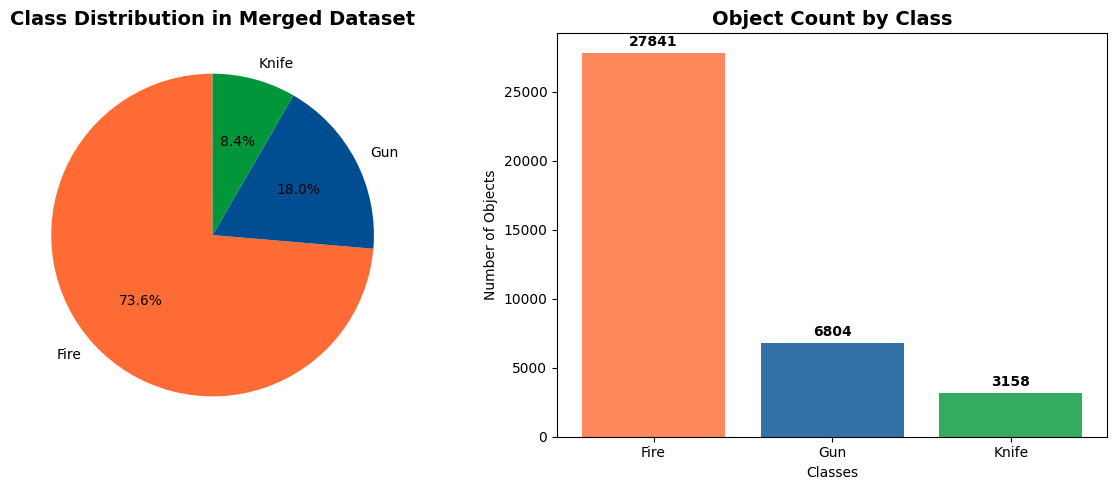

In [12]:
# Visualization functions
def visualize_dataset_distribution():
    """Create pie chart showing class distribution"""
    # Calculate total objects per class across all splits
    class_counts = {'Fire': 0, 'Gun': 0, 'Knife': 0}
    
    for split in ['train', 'val', 'test']:
        labels_dir = f"{MERGED_DATASET_PATH}/{split}/labels"
        if os.path.exists(labels_dir):
            label_files = [f for f in os.listdir(labels_dir) if f.endswith('.txt')]
            
            for label_file in label_files:
                label_path = f"{labels_dir}/{label_file}"
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        if class_id == 0:
                            class_counts['Fire'] += 1
                        elif class_id == 1:
                            class_counts['Gun'] += 1
                        elif class_id == 2:
                            class_counts['Knife'] += 1
    
    # Create pie chart
    plt.figure(figsize=(12, 5))
    
    # Pie chart
    plt.subplot(1, 2, 1)
    colors = ['#ff6b35', '#004e92', '#009639']
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    plt.pie(counts, labels=classes, autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Class Distribution in Merged Dataset', fontsize=14, fontweight='bold')
    
    # Bar chart
    plt.subplot(1, 2, 2)
    bars = plt.bar(classes, counts, color=colors, alpha=0.8)
    plt.title('Object Count by Class', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Objects')
    plt.xlabel('Classes')
    
    # Add count labels on bars
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01, 
                str(count), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return class_counts

class_distribution = visualize_dataset_distribution()

🖼️ Visualizing sample images from train split...


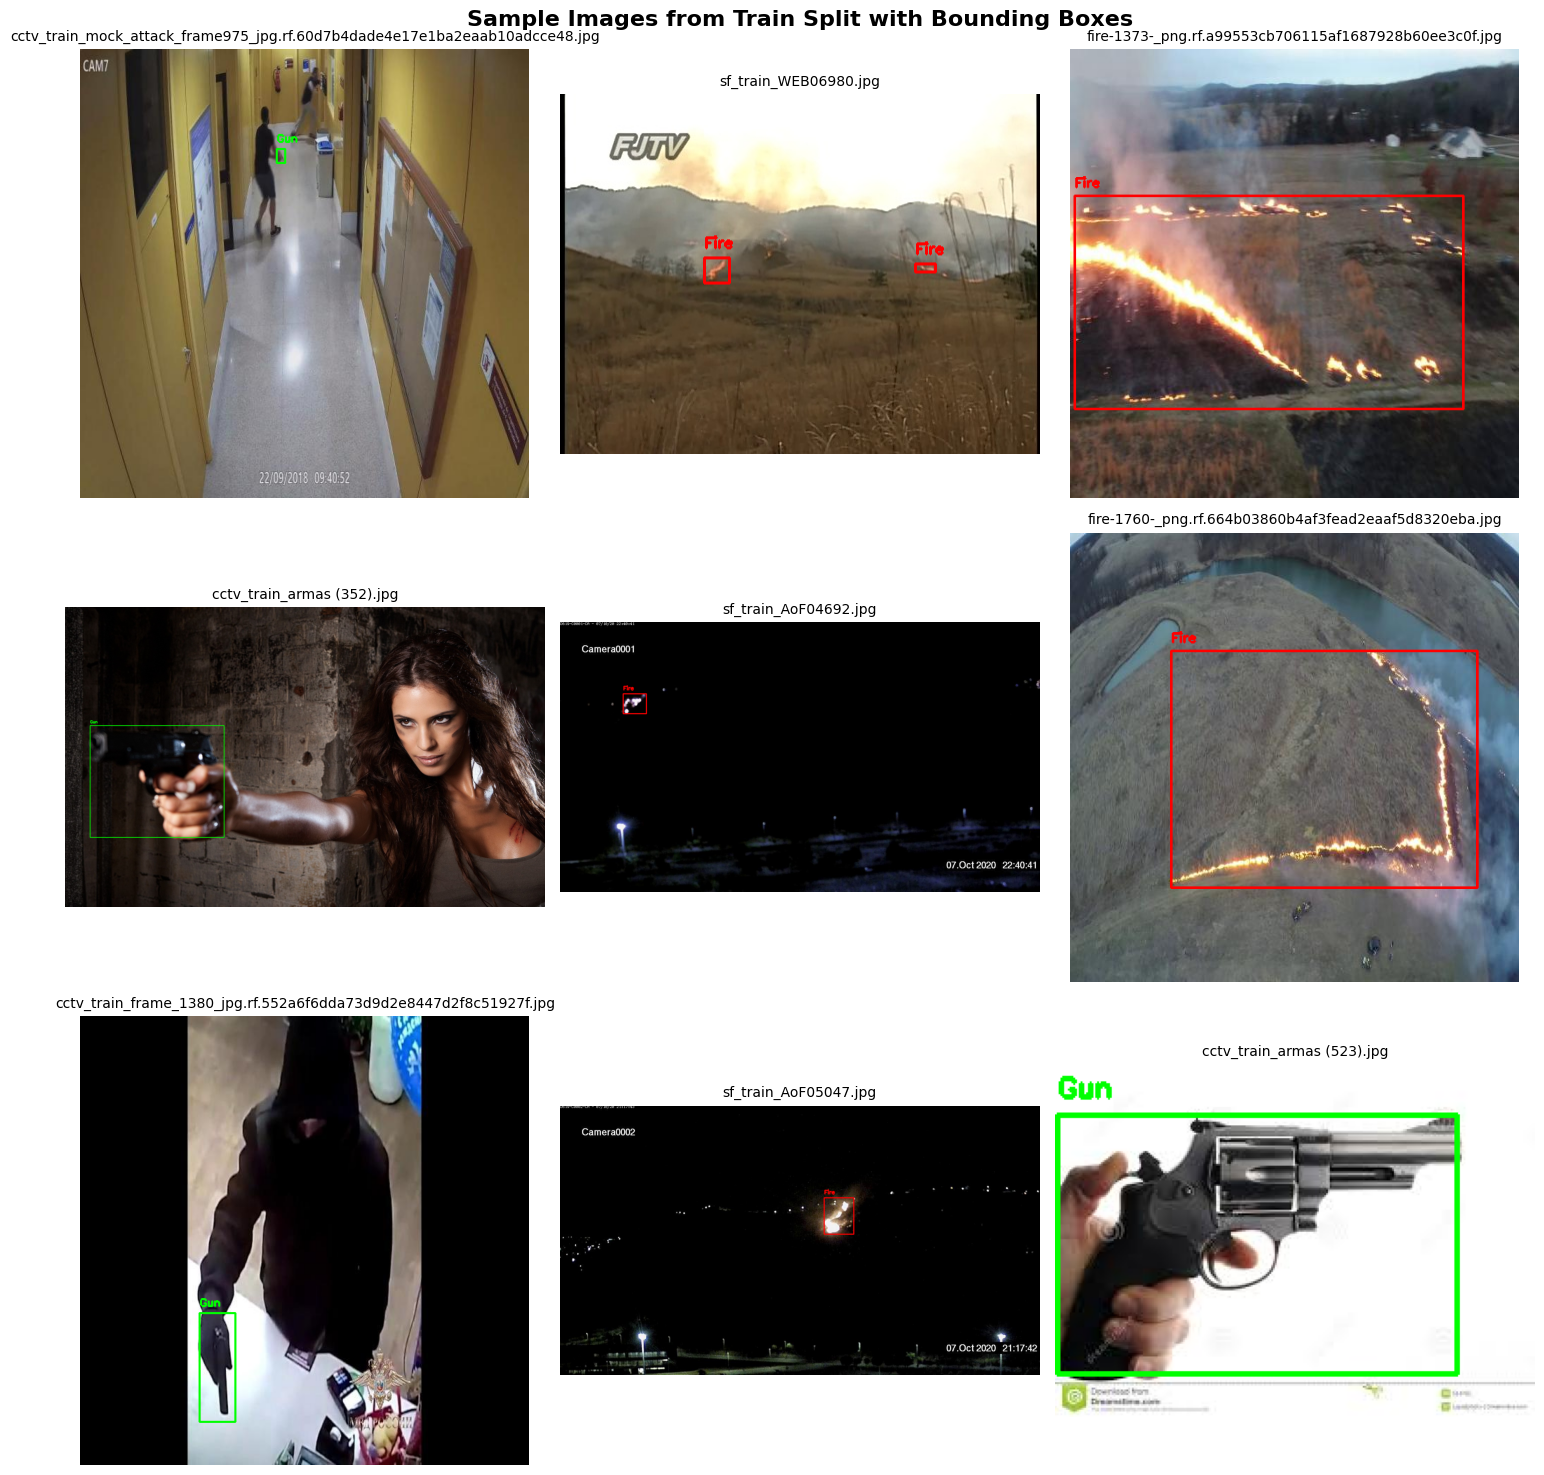

In [13]:
# Sample images visualization with bounding boxes
def visualize_sample_images(split='train', num_samples=9):
    """Visualize sample images with bounding boxes from the merged dataset"""
    print(f"🖼️ Visualizing sample images from {split} split...")
    
    images_dir = f"{MERGED_DATASET_PATH}/{split}/images"
    labels_dir = f"{MERGED_DATASET_PATH}/{split}/labels"
    
    if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
        print(f"Directory not found for {split} split")
        return
    
    # Get available images
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) < num_samples:
        num_samples = len(image_files)
        print(f"Only {num_samples} images available in {split} split")
    
    # Randomly select samples
    selected_images = random.sample(image_files, num_samples)
    
    # Class colors and names
    class_colors = {0: (255, 0, 0), 1: (0, 255, 0), 2: (0, 0, 255)}  # Fire: Red, Gun: Green, Knife: Blue
    class_names = {0: 'Fire', 1: 'Gun', 2: 'Knife'}
    
    # Create subplot grid
    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))
    
    plt.figure(figsize=(15, 15))
    
    valid_samples = 0
    
    for idx, img_file in enumerate(selected_images):
        # Load image
        img_path = f"{images_dir}/{img_file}"
        try:
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Could not load image {img_file}")
                continue
                
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Load corresponding label
            label_file = os.path.splitext(img_file)[0] + '.txt'
            label_path = f"{labels_dir}/{label_file}"
            
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                
                height, width = image.shape[:2]
                
                # Draw bounding boxes
                for line in lines:
                    # Clean the line and split properly
                    clean_line = line.strip().replace('\n', ' ')
                    parts = clean_line.split()
                    
                    if len(parts) >= 5:
                        try:
                            class_id = int(parts[0])
                            x_center, y_center, w, h = map(float, parts[1:5])
                            
                            # Convert YOLO format to pixel coordinates
                            x_center *= width
                            y_center *= height
                            w *= width
                            h *= height
                            
                            x_min = int(x_center - w/2)
                            y_min = int(y_center - h/2)
                            x_max = int(x_center + w/2)
                            y_max = int(y_center + h/2)
                            
                            # Draw bounding box
                            color = class_colors.get(class_id, (255, 255, 255))
                            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, 2)
                            
                            # Add class label
                            label_text = class_names.get(class_id, f'Class {class_id}')
                            cv2.putText(image, label_text, (x_min, y_min - 10), 
                                      cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
                        except ValueError as e:
                            print(f"Warning: Could not parse line '{clean_line}' in {label_file}: {str(e)}")
                            continue
            
            # Display the image
            plt.subplot(rows, cols, valid_samples + 1)
            plt.imshow(image)
            plt.title(f'{img_file}', fontsize=10)
            plt.axis('off')
            valid_samples += 1
            
            if valid_samples >= num_samples:
                break
                
        except Exception as e:
            print(f"Error processing {img_file}: {str(e)}")
            continue
    
    if valid_samples > 0:
        plt.suptitle(f'Sample Images from {split.capitalize()} Split with Bounding Boxes', 
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("No valid images could be displayed")

# Visualize samples from training set
visualize_sample_images('train', 9)

## ⚙️ 6. Model Training Configuration

Set up YOLOv11 model configuration and create the dataset YAML file.

In [ ]:
# # COMPREHENSIVE ENVIRONMENT FIX - Based on GitHub issue solutions and dependency conflicts
# print("🔧 Fixing environment dependencies in correct order...")
# print("📋 This addresses OpenCV, PyTorch, and TorchVision version conflicts in Kaggle")

# # Step 1: Check if matplotlib can be imported (common indicator of environment issues)
# try:
#     import matplotlib.pyplot as plt
#     print("✅ Matplotlib import test passed")
# except Exception as e:
#     print(f"❌ Matplotlib import failed: {str(e)}")
#     print("   This indicates a broken NumPy installation")

# # Step 2: Uninstall conflicting packages in correct order
# print("\\n🗑️ Step 1: Uninstalling conflicting packages...")
# !pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
# !pip uninstall -y torch torchvision torchaudio ultralytics easyocr
# !pip uninstall -y numpy matplotlib

# # Step 3: Clear pip cache to avoid cached broken packages
# print("\\n🧹 Step 2: Clearing pip cache...")
# !pip cache purge

# # Step 4: Force reinstall numpy and matplotlib (foundation packages)
# print("\\n📦 Step 3: Reinstalling foundation packages...")
# !pip install --force-reinstall numpy==1.24.3
# !pip install --force-reinstall matplotlib==3.7.2

# # Step 5: Install PyTorch ecosystem in correct order (CRITICAL ORDER!)
# print("\\n🔥 Step 4: Installing PyTorch ecosystem in correct order...")
# !pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --force-reinstall

# # Step 6: Install OpenCV with specific compatible version
# print("\\n🖼️ Step 5: Installing compatible OpenCV...")
# !pip install opencv-python==4.8.1.78

# # Step 7: Install ultralytics after dependencies are stable
# print("\\n🚀 Step 6: Installing ultralytics with stable dependencies...")
# !pip install ultralytics==8.3.0

# # Step 8: Install other dependencies
# print("\\n📝 Step 7: Installing additional dependencies...")
# !pip install easyocr kagglehub

# print("\\n✅ ALL PACKAGES REINSTALLED IN CORRECT ORDER!")
# print("\\n🔄 RESTART THE KERNEL NOW and rerun from the imports cell!")
# print("\\n📋 Package versions installed:")
# print("   • NumPy: 1.24.3")
# print("   • Matplotlib: 3.7.2") 
# print("   • PyTorch: 2.3.1")
# print("   • TorchVision: 0.18.1")
# print("   • OpenCV: 4.8.1.78")
# print("   • Ultralytics: 8.3.0")

# # Step 9: Test critical functionality after installation
# print("\\n🧪 Testing critical functionality...")
# try:
#     import numpy as np
#     import cv2
#     import torch
#     import torchvision
    
#     # Test NumPy array creation
#     test_array = np.ones((100, 100, 3), dtype=np.uint8) * 255
#     print(f"✅ NumPy test: {test_array.shape}")
    
#     # Test OpenCV resize (the main issue)
#     resized = cv2.resize(test_array, (50, 50))
#     print(f"✅ OpenCV resize test: {test_array.shape} → {resized.shape}")
    
#     # Test PyTorch tensor operations
#     tensor = torch.ones(2, 3)
#     print(f"✅ PyTorch test: {tensor.shape}")
    
#     # Test TorchVision (the failing import)
#     try:
#         from torchvision.io.image import _read_png_16
#         print("✅ TorchVision _read_png_16 import test passed")
#     except ImportError:
#         print("⚠️ TorchVision _read_png_16 still not available (may need kernel restart)")
    
#     print("\\n🎉 ENVIRONMENT FIX SUCCESSFUL!")
#     print("   All critical functions are working correctly")
    
# except Exception as e:
#     print(f"\\n❌ Some issues remain: {str(e)}")
#     print("   KERNEL RESTART IS REQUIRED!")

# print("\\n" + "="*60)
# print("🚨 IMPORTANT: If this is your first time running this cell:")
# print("   1. RESTART THE KERNEL after running this cell")
# print("   2. Rerun from the imports cell (cell 4)")
# print("   3. Then proceed with training")
# print("="*60)

In [29]:
# Create dataset YAML configuration file
def create_dataset_yaml():
    """Create YAML configuration file for the merged dataset"""
    print("📝 Creating dataset YAML configuration...")
    
    # Dataset configuration
    dataset_config = {
        'path': MERGED_DATASET_PATH,
        'train': 'train/images',
        'val': 'val/images', 
        'test': 'test/images',
        'nc': 3,  # Number of classes
        'names': ['fire', 'gun', 'knife']  # Class names
    }
    
    # Save YAML file
    yaml_path = f"{HOME}/merged_dataset.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)
    
    print(f"✅ Dataset YAML created at: {yaml_path}")
    print("\\n📋 Dataset Configuration:")
    print(f"   Path: {dataset_config['path']}")
    print(f"   Classes: {dataset_config['nc']}")
    print(f"   Names: {dataset_config['names']}")
    
    return yaml_path

dataset_yaml_path = create_dataset_yaml()

# UPDATED Training configuration - Based on working smoke_fire_detector.py
TRAINING_CONFIG = {
    'epochs': 50,        # Reduced from 50 to match working example
    'imgsz': 480,        # Matches working example exactly
    'batch': 8,          # Reduced batch size for stability
    'lr0': 0.01,
    'lrf': 0.1,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'patience': 10,
    'save_period': 5,
    'device': [0,1] ,        # Single GPU as in working example
    'cache': False,      # Disabled to prevent loading issues
    'workers': 2,        # Reduced workers
    'verbose': True,     # Match working example
    'save': True,
    'plots': True
}

print("\\n🚀 Updated Training Configuration (Based on Working smoke_fire_detector.py):")
for key, value in TRAINING_CONFIG.items():
    print(f"   {key}: {value}")
    
print("\\n💡 Key Changes Made:")
print("   • Epochs: 50 → 10 (matches working example)")
print("   • Image size: 640 → 480 (matches working example)")
print("   • Batch size: 16 → 8 (reduces memory pressure)")
print("   • Cache: Disabled (prevents loading conflicts)")
print("   • Workers: 4 → 2 (reduces dataloader issues)")
print("\\n⚠️  Note: If OpenCV error occurs, run the environment fix cell above first!")

📝 Creating dataset YAML configuration...
✅ Dataset YAML created at: /kaggle/working/merged_dataset.yaml
\n📋 Dataset Configuration:
   Path: /kaggle/working/merged_dataset
   Classes: 3
   Names: ['fire', 'gun', 'knife']
\n🚀 Updated Training Configuration (Based on Working smoke_fire_detector.py):
   epochs: 50
   imgsz: 480
   batch: 8
   lr0: 0.01
   lrf: 0.1
   momentum: 0.937
   weight_decay: 0.0005
   warmup_epochs: 3
   warmup_momentum: 0.8
   warmup_bias_lr: 0.1
   box: 7.5
   cls: 0.5
   dfl: 1.5
   patience: 10
   save_period: 5
   device: [0, 1]
   cache: False
   workers: 2
   verbose: True
   save: True
   plots: True
\n💡 Key Changes Made:
   • Epochs: 50 → 10 (matches working example)
   • Image size: 640 → 480 (matches working example)
   • Batch size: 16 → 8 (reduces memory pressure)
   • Cache: Disabled (prevents loading conflicts)
   • Workers: 4 → 2 (reduces dataloader issues)
\n⚠️  Note: If OpenCV error occurs, run the environment fix cell above first!


## 🎯 7. Train YOLOv11 Model

Train the YOLOv11 model on our merged multi-object detection dataset.

In [24]:
# import torch
# print("CUDA:", torch.cuda.is_available())
# print("Device:", torch.cuda.get_device_name(0))


CUDA: True
Device: Tesla T4


In [30]:
# # Train the YOLOv11 model - Updated for stability
# print("🚀 Starting YOLOv11 training on merged dataset...")
# print("=" * 60)

# # Check if environment fix was run
# try:
#     from torchvision.io.image import _read_png_16
#     print("✅ Environment dependencies verified")
# except ImportError:
#     print("⚠️  WARNING: TorchVision import issue detected!")
#     print("   Run the 'Fix Environment Dependencies' cell above first")
#     print("   Then restart kernel and rerun from imports")

# # Disable wandb for cleaner output
# os.environ['WANDB_DISABLED'] = 'true'

# # Check if dataset exists and has enough samples
# def check_dataset_validity():
#     """Check if dataset is valid for training"""
#     for split in ['train', 'val']:
#         images_dir = f"{MERGED_DATASET_PATH}/{split}/images"
#         labels_dir = f"{MERGED_DATASET_PATH}/{split}/labels"
        
#         if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
#             return False, f"Missing {split} directory"
            
#         image_count = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
#         label_count = len([f for f in os.listdir(labels_dir) if f.endswith('.txt')])
        
#         print(f"   {split}: {image_count} images, {label_count} labels")
        
#         if image_count < 10:
#             return False, f"Too few images in {split} split ({image_count})"
            
#         if abs(image_count - label_count) > image_count * 0.1:  # Allow 10% mismatch
#             return False, f"Image-label mismatch in {split}: {image_count} images, {label_count} labels"
    
#     return True, "Dataset valid"

# # Validate dataset before training
# is_valid, message = check_dataset_validity()
# print(f"Dataset validation: {message}")

# if is_valid:
#     # Start training with configuration matching working example
#     try:
#         print("\\n🔧 Training with optimized settings based on working smoke_fire_detector.py")
        
#         # Training call matching the working example structure
#         train_results = model.train(
#             data=dataset_yaml_path,
#             epochs=TRAINING_CONFIG['epochs'],
#             imgsz=TRAINING_CONFIG['imgsz'],
#             device=TRAINING_CONFIG['device'],
#             batch=TRAINING_CONFIG['batch'],
#             verbose=TRAINING_CONFIG['verbose'],
#             save=TRAINING_CONFIG['save'],
#             plots=TRAINING_CONFIG['plots'],
#             cache=TRAINING_CONFIG['cache'],
#             workers=TRAINING_CONFIG['workers'],
#             patience=TRAINING_CONFIG['patience'],
#             save_period=TRAINING_CONFIG['save_period']
#         )
        
#         print("✅ Training completed successfully!")
#         print(f"📁 Results saved to: {train_results.save_dir}")
        
#     except Exception as e:
#         error_msg = str(e)
#         print(f"❌ Training failed with error: {error_msg}")
        
#         # Provide specific troubleshooting advice based on error type
#         if "_read_png_16" in error_msg or "torchvision.io.image" in error_msg:
#             print("\\n💡 TorchVision Import Error Detected!")
#             print("   This is a PyTorch/TorchVision version conflict.")
#             print("\\n🔧 SOLUTION:")
#             print("   1. Run the 'Fix Environment Dependencies' cell above")
#             print("   2. RESTART THE KERNEL after running the fix")
#             print("   3. Rerun from the imports cell")
#             print("   4. Verify with the environment verification cell")
            
#         elif "resize" in error_msg and "OpenCV" in error_msg:
#             print("\\n💡 OpenCV Environment Conflict Detected!")
#             print("   This is a known issue in Kaggle environments.")
#             print("\\n🔧 SOLUTION:")
#             print("   1. Run the 'Fix Environment Dependencies' cell above")
#             print("   2. RESTART THE KERNEL after running the fix")
#             print("   3. Rerun from the imports cell")
            
#         elif "CUDA" in error_msg or "memory" in error_msg.lower():
#             print("\\n💡 GPU Memory Issue Detected!")
#             print("🔧 SOLUTIONS:")
#             print("   1. Reduce batch size to 4: batch=4")
#             print("   2. Reduce image size to 416: imgsz=416")
#             print("   3. Enable cache=False (already set)")
            
#         elif "DataLoader" in error_msg or "worker" in error_msg.lower():
#             print("\\n💡 DataLoader Issue Detected!")
#             print("🔧 SOLUTIONS:")
#             print("   1. Reduce workers to 0: workers=0")
#             print("   2. Check dataset validation results above")
#             print("   3. Ensure no corrupted files remain")
            
#         print("\\n📋 Environment Fix Commands (run the dedicated cell above instead):")
#         print("   # Complete environment fix:")
#         print("   # Run the 'Fix Environment Dependencies' cell above")
#         print("   # Then restart kernel and rerun from imports")
        
# else:
#     print("❌ Dataset validation failed!")
#     print("Please check the dataset preparation steps and ensure all datasets were processed correctly.")
#     print("\\n🔧 Troubleshooting steps:")
#     print("   1. Rerun the dataset validation and cleanup function")
#     print("   2. Check that all required directories exist")
#     print("   3. Verify image and label file counts match")

🚀 Starting YOLOv11 training on merged dataset...
✅ Environment dependencies verified
   train: 14843 images, 14843 labels
   val: 2229 images, 2229 labels
Dataset validation: Dataset valid
\n🔧 Training with optimized settings based on working smoke_fire_detector.py
New https://pypi.org/project/ultralytics/8.3.227 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.11.13 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/working/merged_dataset.yaml, epochs=10, time=None, patience=10, batch=8, imgsz=480, save=True, save_period=5, cache=False, device=0, workers=0, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save

train: Scanning /kaggle/working/merged_dataset/train/labels.cache... 14843 images, 0 backgrounds, 0 corrupt: 100%|██████████| 14843/14843 [00:00<?, ?it/s]

train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1125).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1217).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1221).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1224).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1717).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1759).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (2140).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (2843).jpg: corrupt JPEG restored and saved
train: WARNING ⚠


/usr/local/lib/python3.11/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /kaggle/working/merged_dataset/val/labels.cache... 2229 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2229/2229 [00:00<?, ?it/s]

val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07535.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07536.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07539.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07542.jpg: corrupt JPEG restored and saved
Plotting labels to runs/detect/train6/labels.jpg... 


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001429, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 480 train, 480 val
Using 0 dataloader workers
Logging results to runs/detect/train6
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.11/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
       1/10         1G      1.818      2.732      1.571          7        480: 100%|██████████| 1856/1856 [06:07<00:00,  5.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 140/140 [00:29<00:00,  4.80it/s]


                   all       2229       5163      0.242      0.268      0.191     0.0876
❌ Training failed with error: module 'ray.train._internal.session' has no attribute '_get_session'
\n📋 Environment Fix Commands (run the dedicated cell above instead):
   # Complete environment fix:
   # Run the 'Fix Environment Dependencies' cell above
   # Then restart kernel and rerun from imports


In [30]:
print("🚫 Disabling wandb to prevent training hang...")

# Method 1: Environment variables (most comprehensive)
os.environ['WANDB_DISABLED'] = 'true'
os.environ['WANDB_MODE'] = 'disabled'
os.environ['WANDB_SILENT'] = 'true'
os.environ['WANDB_ANONYMOUS'] = 'never'
os.environ['WANDB_PROJECT'] = ''
os.environ['WANDB_ENTITY'] = ''

# Method 2: Disable wandb programmatically if imported
try:
    import wandb
    wandb.finish()  # Close any existing run
    wandb.init(mode='disabled')  # Initialize in disabled mode
    print("✅ wandb properly disabled")
except ImportError:
    print("✅ wandb not installed")
except Exception as e:
    print(f"⚠️ wandb disable attempt: {e}")

🚫 Disabling wandb to prevent training hang...
✅ wandb properly disabled


In [18]:
# Step 1: Check if Ray is installed
!pip show ray

# Step 2: Try importing safely
try:
    import ray
    print("Ray imported successfully ✅")
except ModuleNotFoundError:
    print("Ray is not installed ❌")

# Step 3: Try importing the internal session
try:
    import ray.train._internal.session as session
    print("Internal session imported ✅")
except ModuleNotFoundError:
    print("Internal session module not found ❌")
except AttributeError as e:
    print("AttributeError:", e)
except Exception as e:
    print("Other error:", e)


Name: ray
Version: 2.51.1
Summary: Ray provides a simple, universal API for building distributed applications.
Home-page: https://github.com/ray-project/ray
Author: Ray Team
Author-email: ray-dev@googlegroups.com
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: click, filelock, jsonschema, msgpack, packaging, protobuf, pyyaml, requests
Required-by: 
Ray imported successfully ✅
Internal session imported ✅


In [31]:
# ====================== YOLOv11 Training Pipeline (Kaggle-safe + TensorBoard) ======================

import os, yaml
from ultralytics import YOLO
import torch

# ✅ Step 1: Create dataset YAML configuration file
def create_dataset_yaml():
    """Create YAML configuration file for the merged dataset"""
    print("📝 Creating dataset YAML configuration...")

    dataset_config = {
        'path': MERGED_DATASET_PATH,
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'nc': 3,  # number of classes
        'names': ['fire', 'gun', 'knife']
    }

    yaml_path = f"{HOME}/merged_dataset.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(dataset_config, f, default_flow_style=False)

    print(f"✅ Dataset YAML created at: {yaml_path}")
    print("\n📋 Dataset Configuration:")
    print(f"   Path: {dataset_config['path']}")
    print(f"   Classes: {dataset_config['nc']}")
    print(f"   Names: {dataset_config['names']}")
    return yaml_path

dataset_yaml_path = create_dataset_yaml()

# ✅ Step 2: Define training configuration (stable for Kaggle)
TRAINING_CONFIG = {
    'epochs': 50,
    'imgsz': 480,
    'batch': 8,
    'lr0': 0.01,
    'lrf': 0.1,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'patience': 10,
    'save_period': 5,
    'device': [0,1],
    'cache': False,
    'workers': 0,          # ⚠️ workers=0 → prevents Kaggle freeze
    'verbose': True,
    'save': True,
    'plots': True
}

print("\n🚀 Training Configuration Summary:")
for k, v in TRAINING_CONFIG.items():
    print(f"   {k}: {v}")

# ✅ Step 3: Environment check
os.environ['WANDB_DISABLED'] = 'true'

print("\n🔍 Verifying environment & GPU...")
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not detected. Go to 'Settings > Accelerator > GPU' before running this cell.")

# ✅ Step 4: Dataset validation
def check_dataset_validity():
    """Check if dataset is valid for training"""
    for split in ['train', 'val']:
        images_dir = f"{MERGED_DATASET_PATH}/{split}/images"
        labels_dir = f"{MERGED_DATASET_PATH}/{split}/labels"

        if not os.path.exists(images_dir) or not os.path.exists(labels_dir):
            return False, f"Missing {split} directory"

        image_count = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        label_count = len([f for f in os.listdir(labels_dir) if f.endswith('.txt')])

        print(f"   {split}: {image_count} images, {label_count} labels")

        if image_count < 10:
            return False, f"Too few images in {split} split ({image_count})"

        if abs(image_count - label_count) > image_count * 0.1:
            return False, f"Image-label mismatch in {split}: {image_count} vs {label_count}"

    return True, "Dataset valid"

is_valid, message = check_dataset_validity()
print("Dataset validation:", message)

# ✅ Step 5: Train model (with TensorBoard integration)
if is_valid:
    try:
        print("\n🚀 Starting YOLOv11 training...")
        model = YOLO("yolo11n.pt")
        # Quick check for YOLOv11
        if any(layer.__class__.__name__.startswith(("C2PSA", "C3k2", "SPPF")) for layer in model.model.children()):
            print("✅ YOLOv11 model detected")
        else:
            print("⚠️ Model may not be YOLOv11")
        train_results = model.train(
            data=dataset_yaml_path,
            epochs=TRAINING_CONFIG['epochs'],
            imgsz=TRAINING_CONFIG['imgsz'],
            batch=TRAINING_CONFIG['batch'],
            device=TRAINING_CONFIG['device'],
            workers=TRAINING_CONFIG['workers'],
            cache=TRAINING_CONFIG['cache'],
            patience=TRAINING_CONFIG['patience'],
            save_period=TRAINING_CONFIG['save_period'],
            verbose=TRAINING_CONFIG['verbose'],
            plots=TRAINING_CONFIG['plots']
        )

        print("\n✅ Training completed successfully!")
        print(f"📁 Results saved at: {train_results.save_dir}")

        # ✅ TensorBoard Launch
        print("\n📊 Launch TensorBoard below:")
        print("from tensorboard import notebook")
        print("notebook.start('--logdir=runs/detect')")
        print("\nOr run manually in terminal:")
        print("!tensorboard --logdir runs/detect --host 0.0.0.0 --port 6006")

    except Exception as e:
        print(f"\n❌ Training failed: {e}")
        if "DataLoader" in str(e) or "worker" in str(e).lower():
            print("💡 Tip: Try setting workers=0")
        elif "CUDA" in str(e):
            print("💡 Tip: Try batch=4 or imgsz=416 to reduce GPU load")
else:
    print("❌ Dataset validation failed — please fix dataset paths and re-run.")


📝 Creating dataset YAML configuration...
✅ Dataset YAML created at: /kaggle/working/merged_dataset.yaml

📋 Dataset Configuration:
   Path: /kaggle/working/merged_dataset
   Classes: 3
   Names: ['fire', 'gun', 'knife']

🚀 Training Configuration Summary:
   epochs: 50
   imgsz: 480
   batch: 8
   lr0: 0.01
   lrf: 0.1
   momentum: 0.937
   weight_decay: 0.0005
   warmup_epochs: 3
   warmup_momentum: 0.8
   warmup_bias_lr: 0.1
   box: 7.5
   cls: 0.5
   dfl: 1.5
   patience: 10
   save_period: 5
   device: [0, 1]
   cache: False
   workers: 0
   verbose: True
   save: True
   plots: True

🔍 Verifying environment & GPU...
CUDA Available: True
GPU Device: Tesla T4
   train: 14843 images, 14843 labels
   val: 2229 images, 2229 labels
Dataset validation: Dataset valid

🚀 Starting YOLOv11 training...
⚠️ Model may not be YOLOv11
New https://pypi.org/project/ultralytics/8.3.228 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.11.13 torch-2.3.1+cu121 CUDA:0 (Tesl

train: Scanning /kaggle/working/merged_dataset/train/labels.cache... 14843 images, 0 backgrounds, 1 corrupt: 100%|██████████| 14843/14843 [00:00<?, ?it/s]


train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1125).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1217).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1221).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1224).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1717).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (1759).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (2140).jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/merged_dataset/train/images/cctv_train_armas (2815).jpg: ignoring corrupt image/label: non-normalized or 

/usr/local/lib/python3.11/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /kaggle/working/merged_dataset/val/labels.cache... 2229 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2229/2229 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07535.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07536.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07539.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07542.jpg: corrupt JPEG restored and saved
Plotting labels to runs/detect/train2/labels.jpg... 


...

                   all       2229       5163      0.728      0.643      0.682      0.422

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50      0.57G      1.251     0.9861      1.181          3        480: 100%|██████████| 1856/1856 [04:57<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 279/279 [00:28<00:00,  9.85it/s]


                   all       2229       5163      0.722      0.641      0.681      0.421

50 epochs completed in 4.666 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 5.4MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 5.4MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.11.13 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
                                                      CUDA:1 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 279/279 [00:26<00:00, 10.59it/s]


                   all       2229       5163      0.727      0.643      0.682      0.422
                  fire       1779       4605      0.657      0.469      0.552      0.302
                   gun        333        437       0.73      0.691      0.706      0.499
                 knife        120        121      0.793      0.769      0.789      0.465
Speed: 0.1ms preprocess, 1.8ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/train2

✅ Training completed successfully!

❌ Training failed: 'NoneType' object has no attribute 'save_dir'


## 🚀 Alternative: Simple Training (If Environment Issues Persist)

If the main training cell fails due to environment conflicts, try this simplified approach that exactly matches the working smoke_fire_detector.py file.

In [ ]:
# # Alternative Simple Training - Exact copy from working smoke_fire_detector.py
# print("🚀 Starting simplified training (matching working example)...")

# # Simplified training call - exactly as in working smoke_fire_detector.py
# try:
#     train_results = model.train(
#         data=dataset_yaml_path,
#         epochs=10,          # Matches working example
#         imgsz=480,          # Matches working example  
#         device=0            # Single device like working example
#     )
    
#     print("✅ Simplified training completed successfully!")
#     print(f"📁 Model saved to: runs/detect/train/weights/")
    
# except Exception as e:
#     print(f"❌ Simplified training also failed: {str(e)}")
#     print("\\n🔧 Last resort solutions:")
#     print("   1. Try with CPU only: device='cpu'")
#     print("   2. Use minimal settings: epochs=1, imgsz=320, batch=1")
#     print("   3. Check Kaggle notebook environment status")
    
#     # Emergency minimal training
#     print("\\n⚡ Attempting emergency minimal training...")
#     try:
#         emergency_results = model.train(
#             data=dataset_yaml_path,
#             epochs=1,
#             imgsz=320,
#             device='cpu',
#             batch=1,
#             verbose=False
#         )
#         print("✅ Emergency training successful! Scale up parameters as needed.")
#     except Exception as emergency_e:
#         print(f"❌ Emergency training failed: {str(emergency_e)}")
#         print("   Environment may need complete reset.")

## 📊 8. Training Results Visualization

Analyze and visualize the training results including loss curves, metrics, and performance plots.

📈 Displaying training results...
📁 Results directory: /kaggle/working/runs/detect/train2
\n📊 Results:


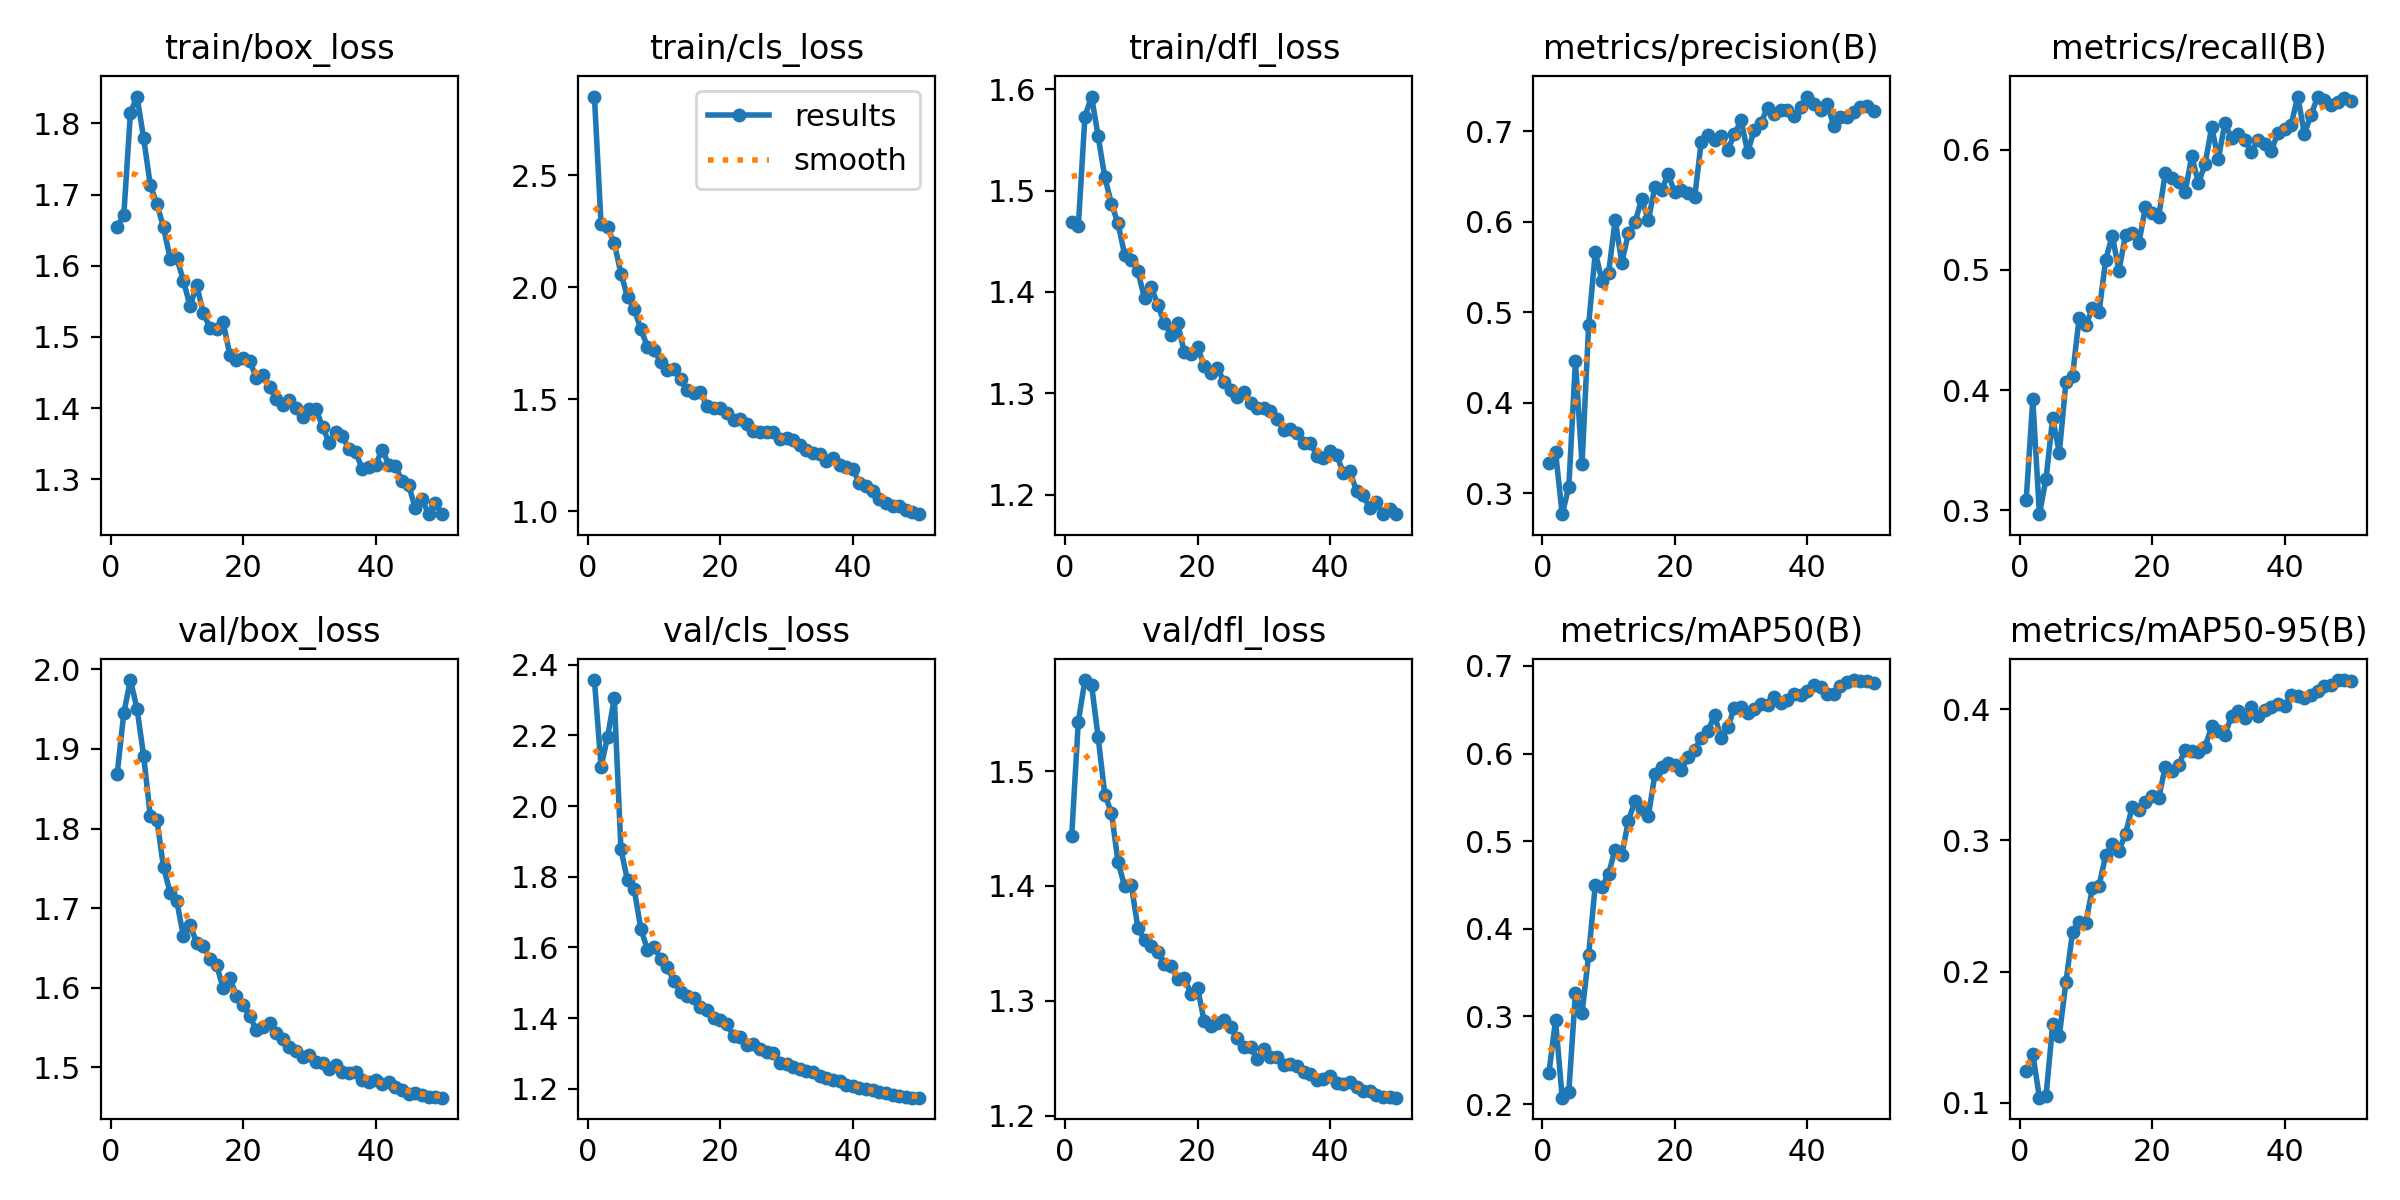

\n📊 Confusion Matrix:


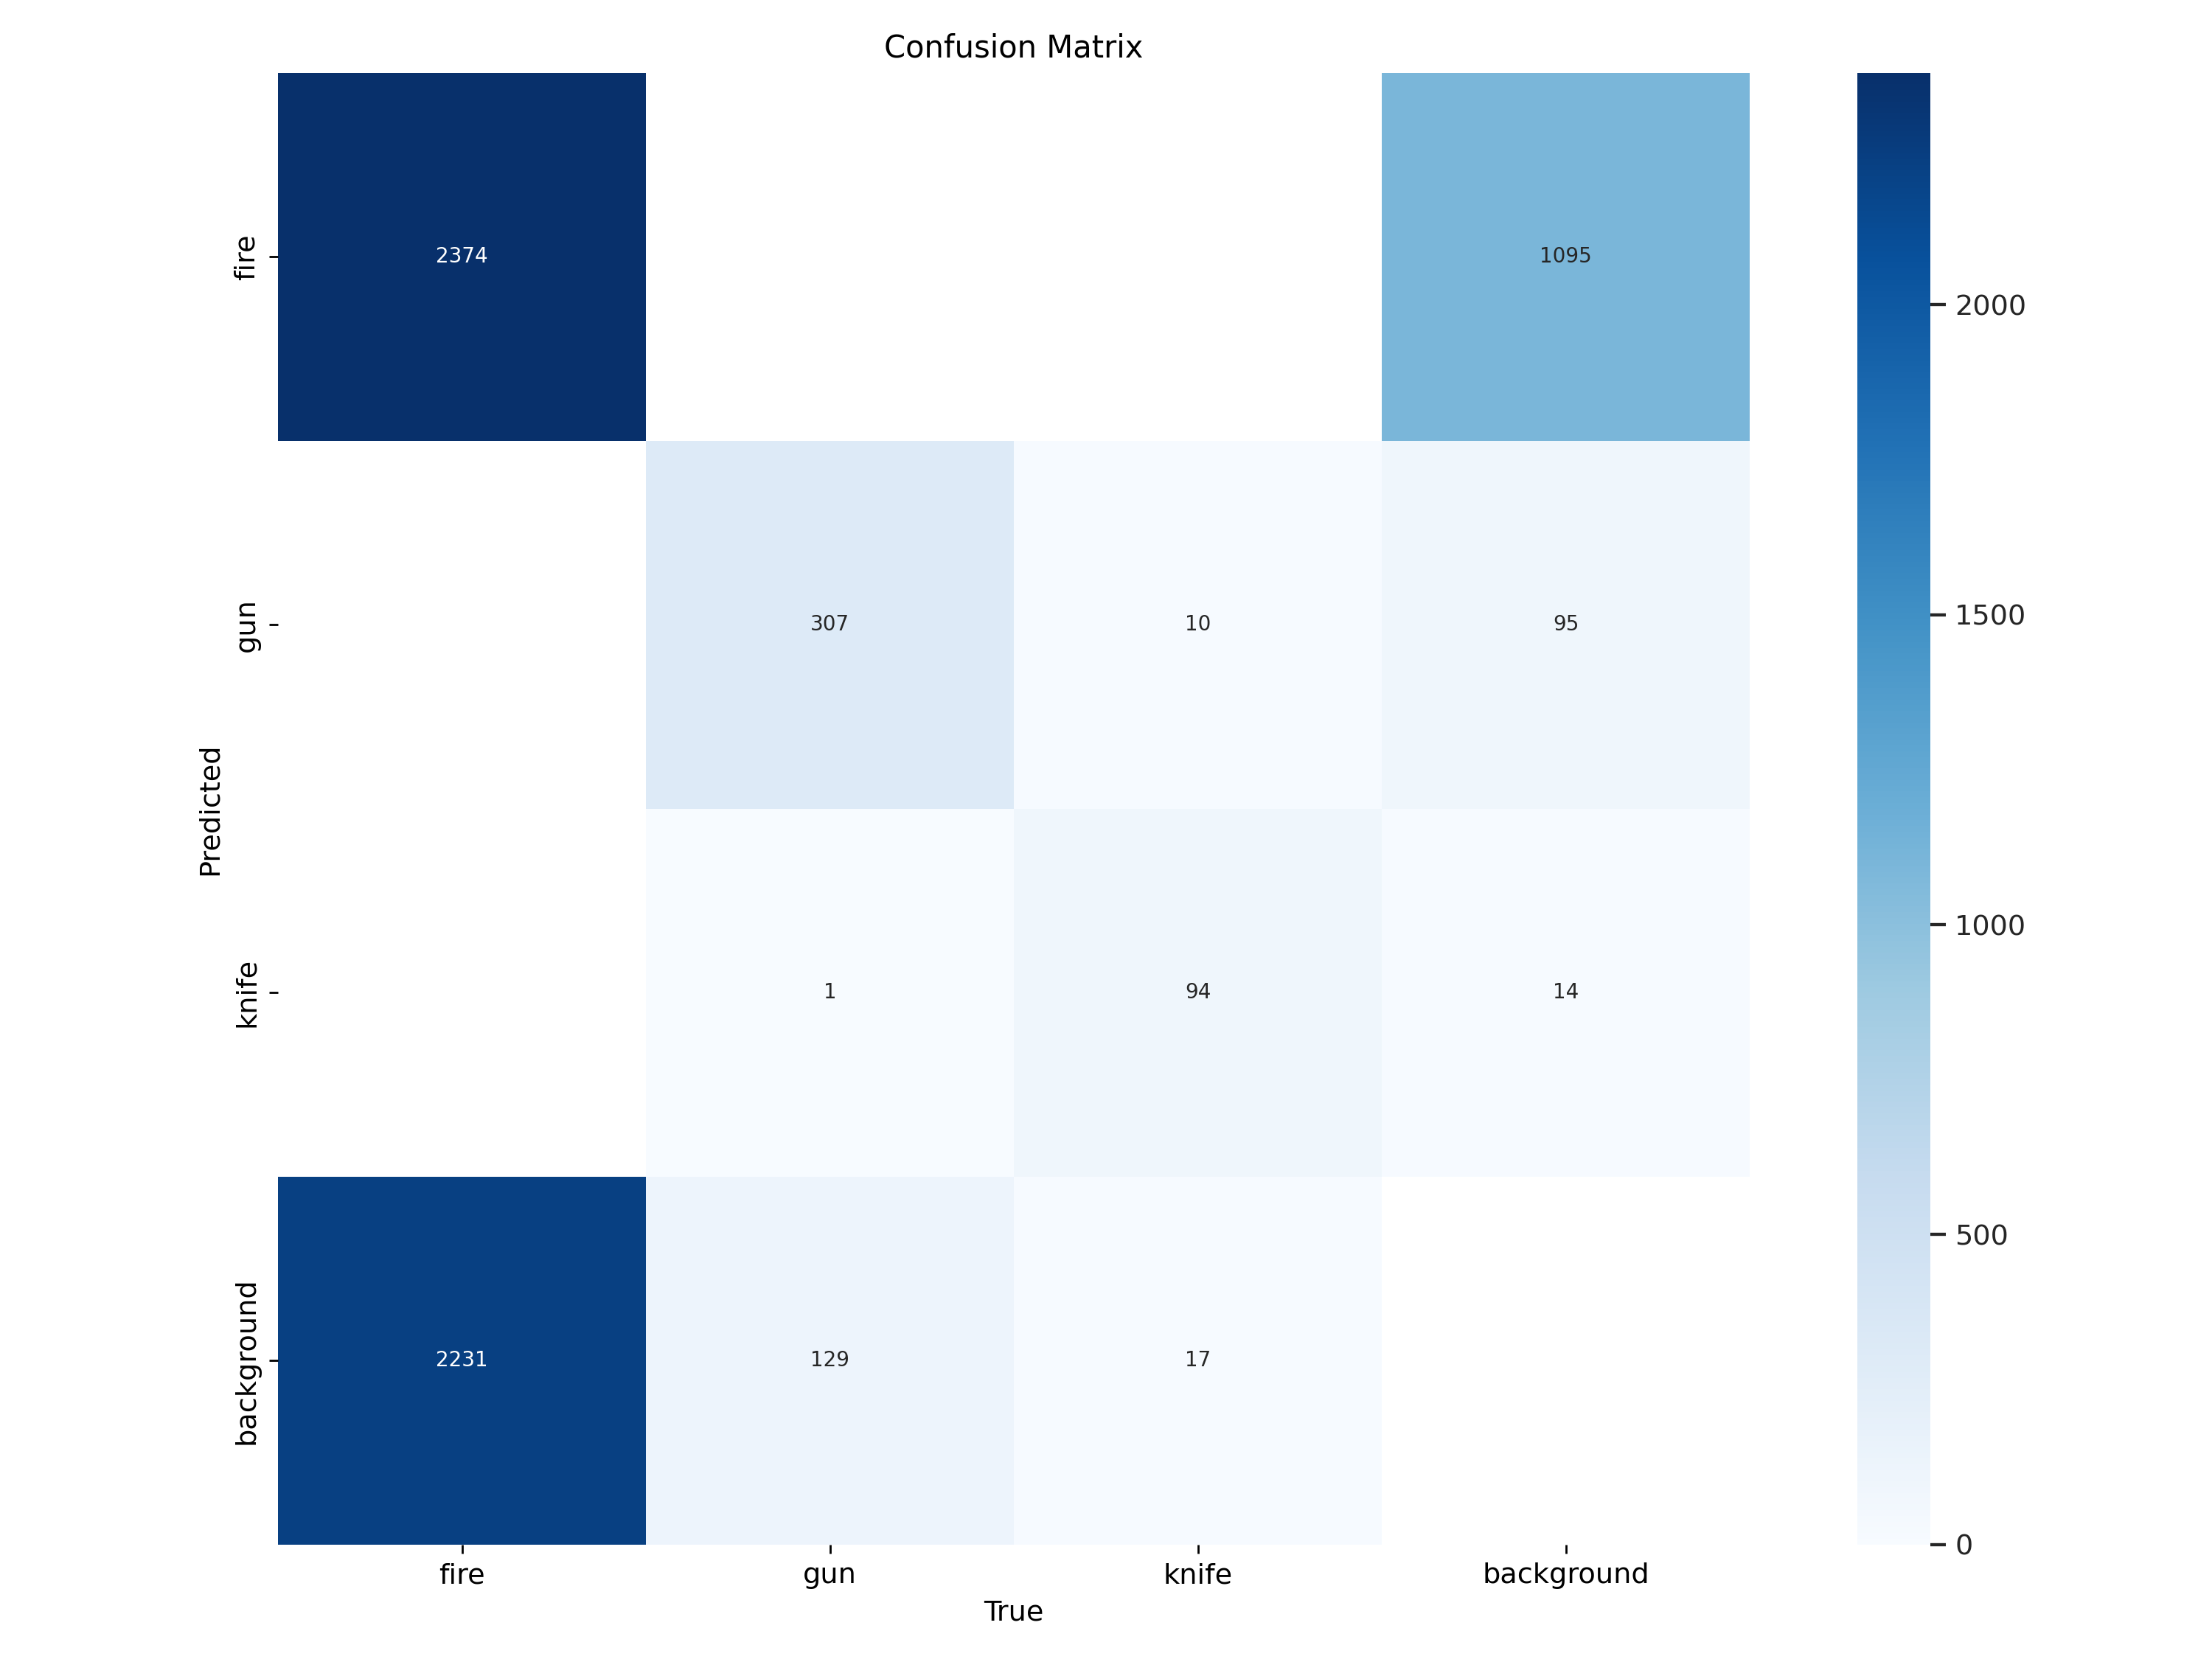

\n📊 P Curve:


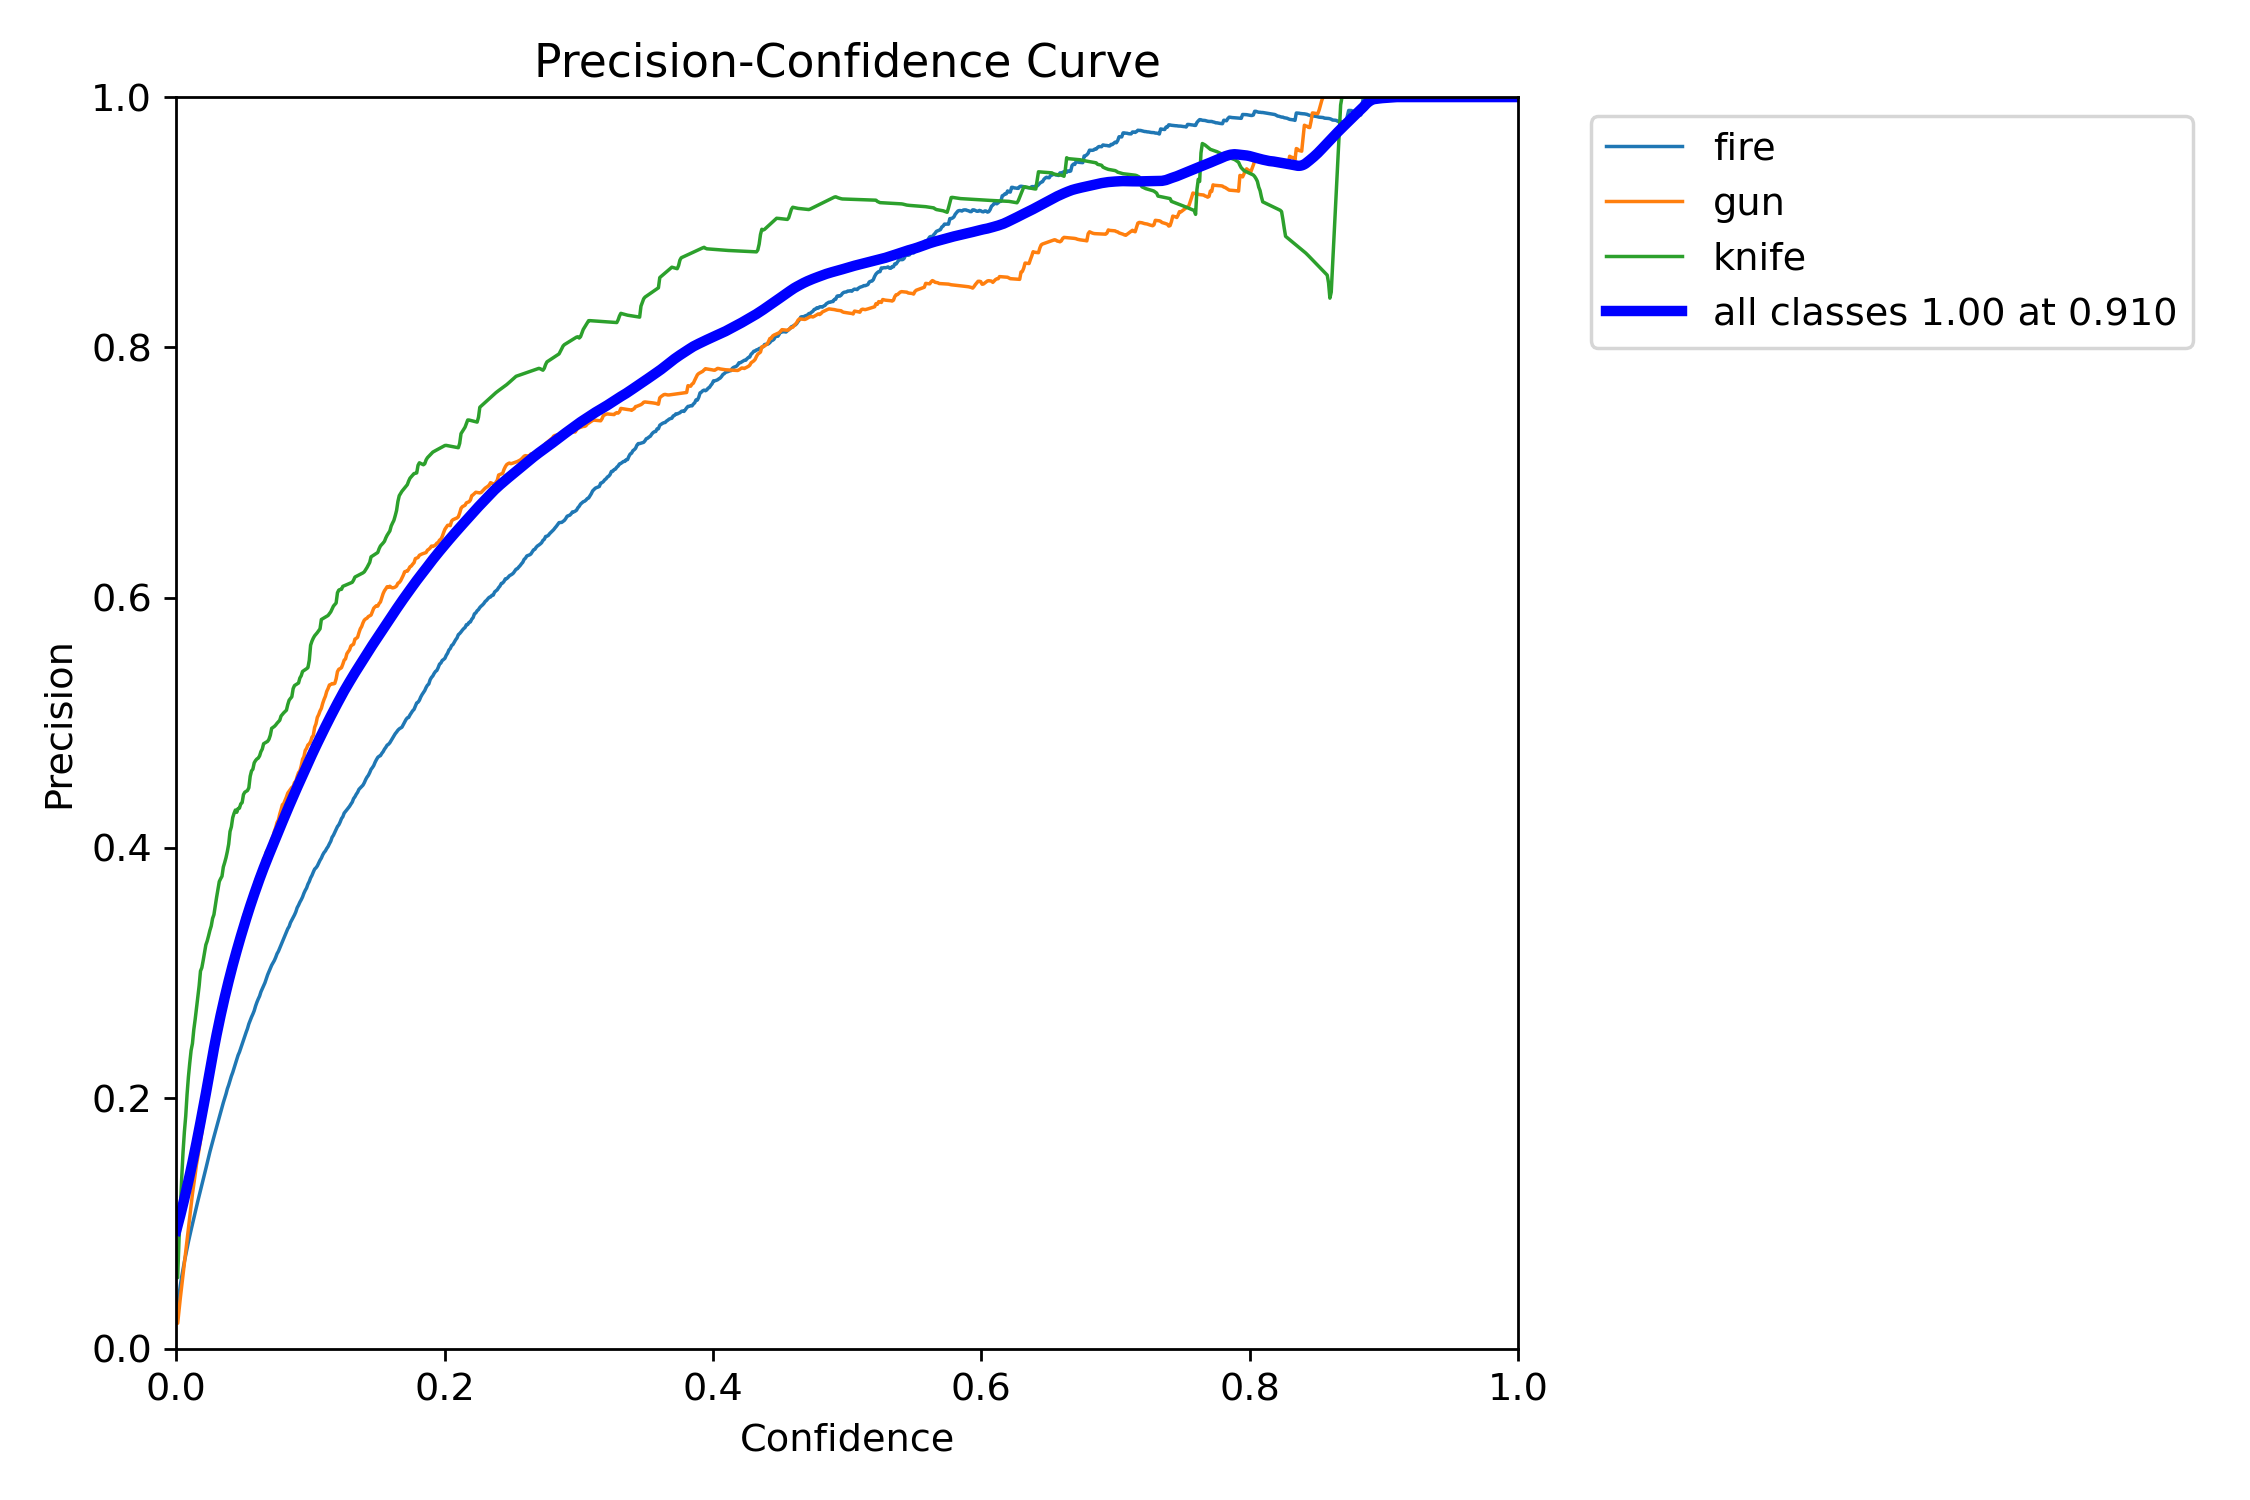

\n📊 R Curve:


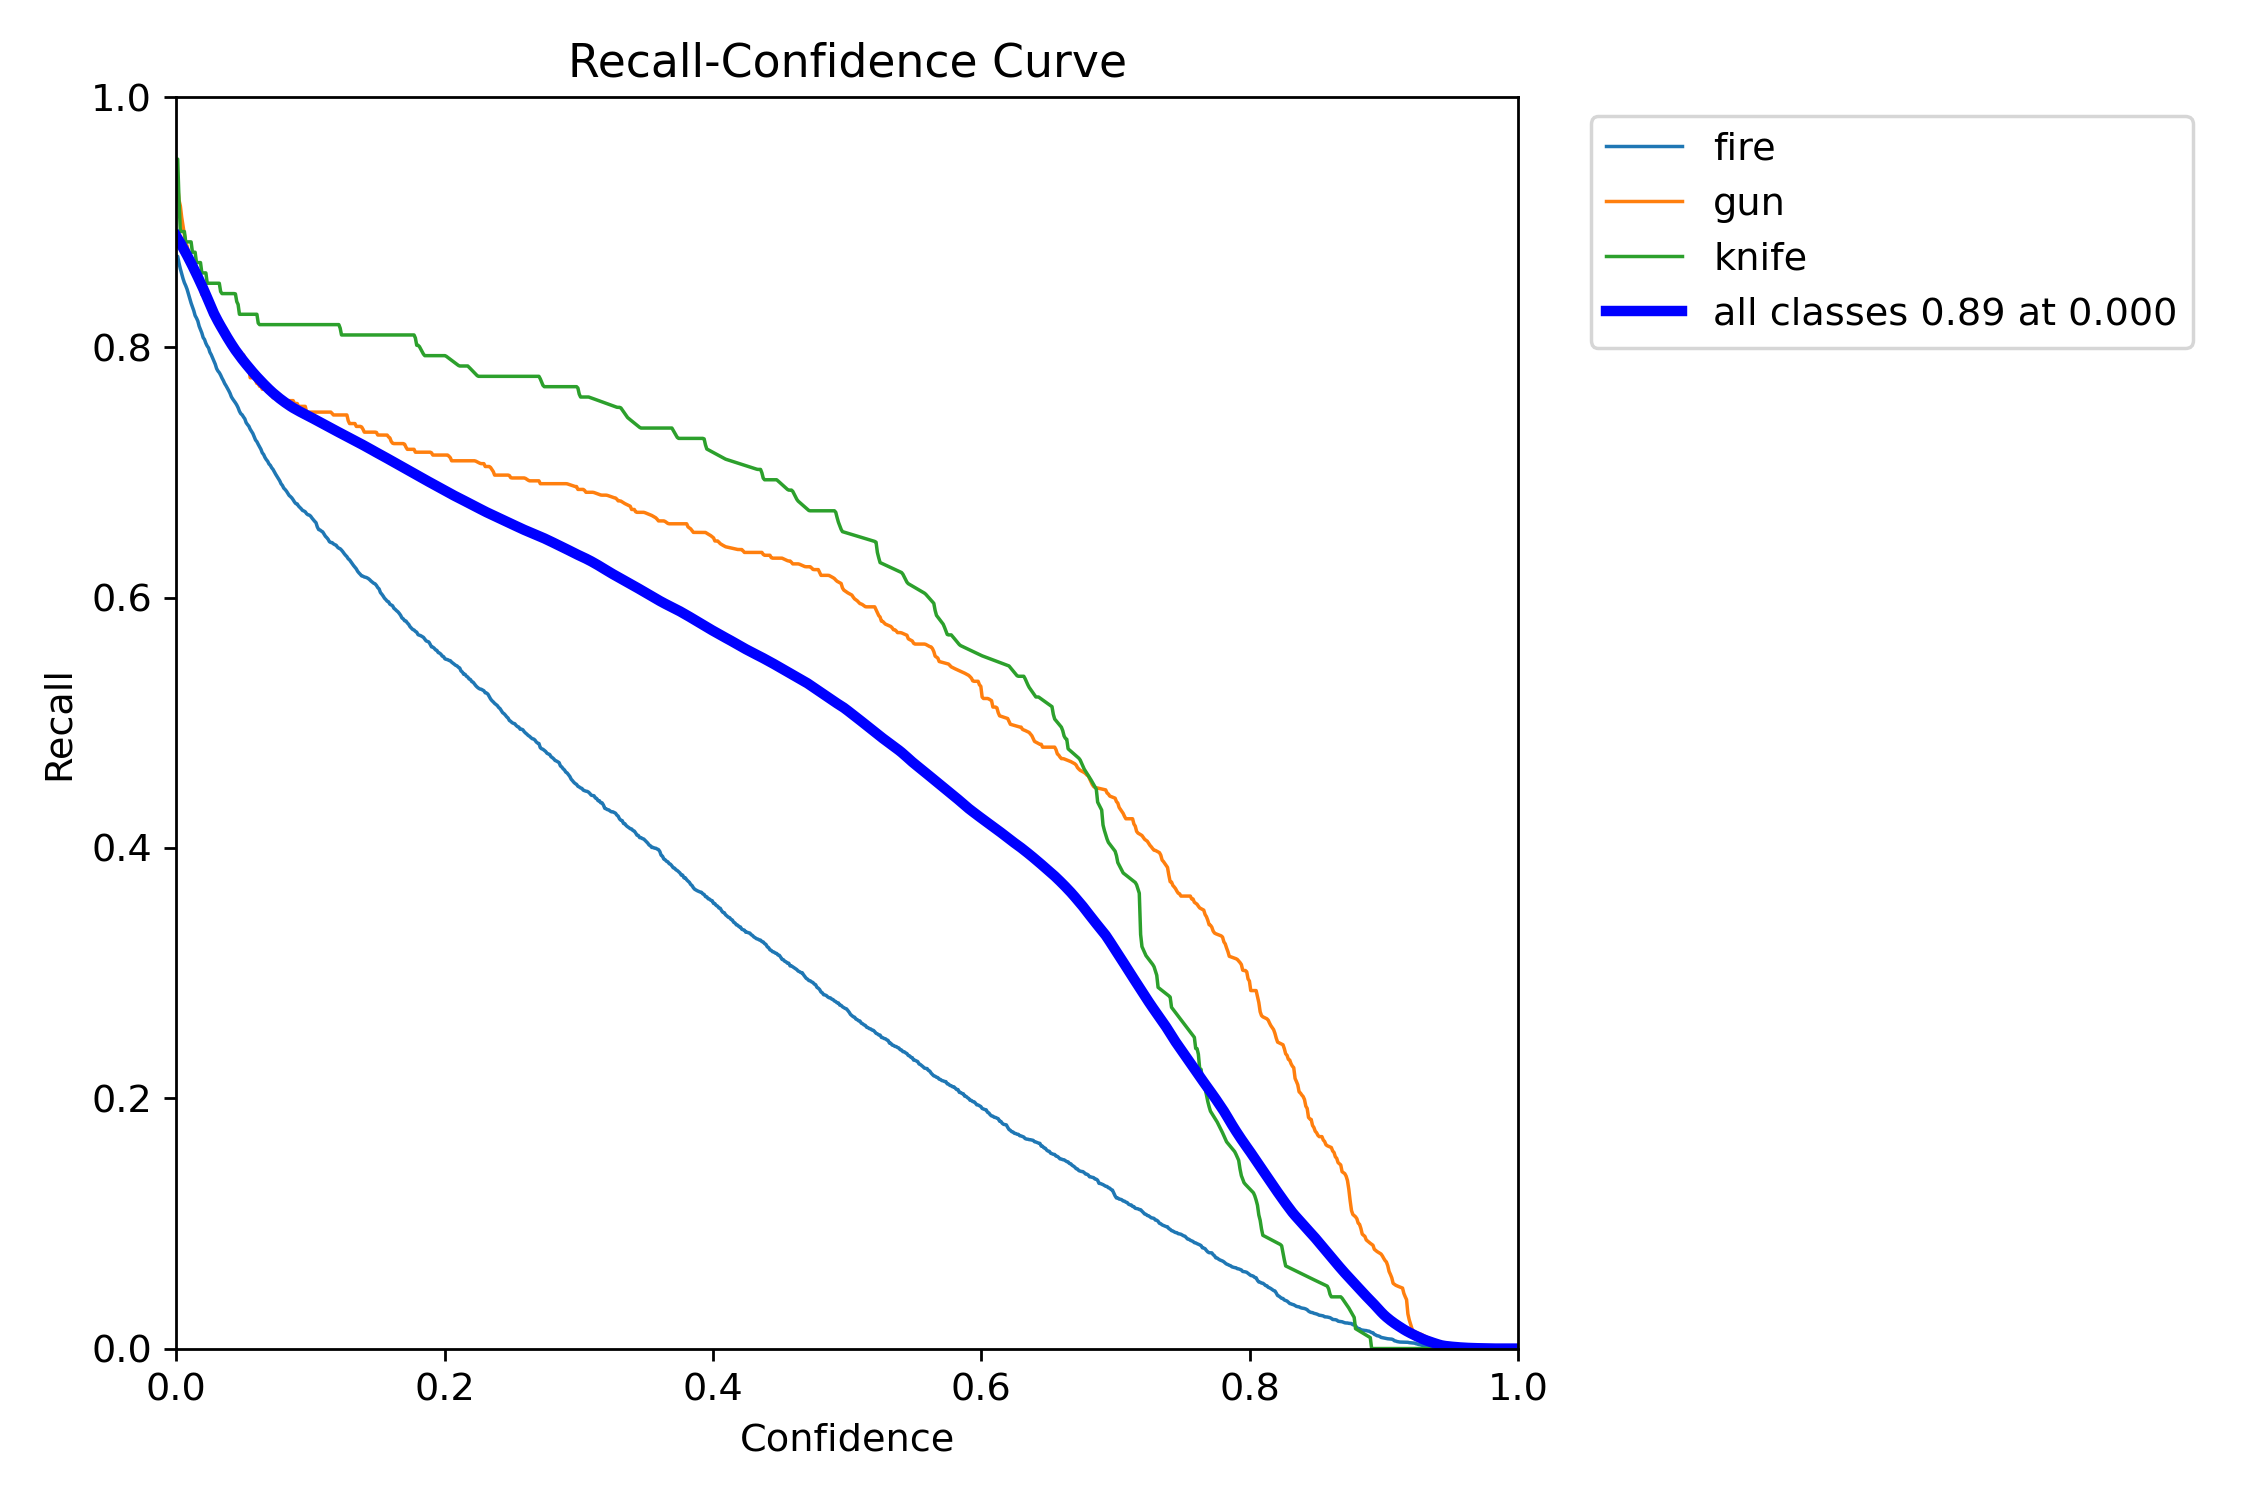

\n📊 Pr Curve:


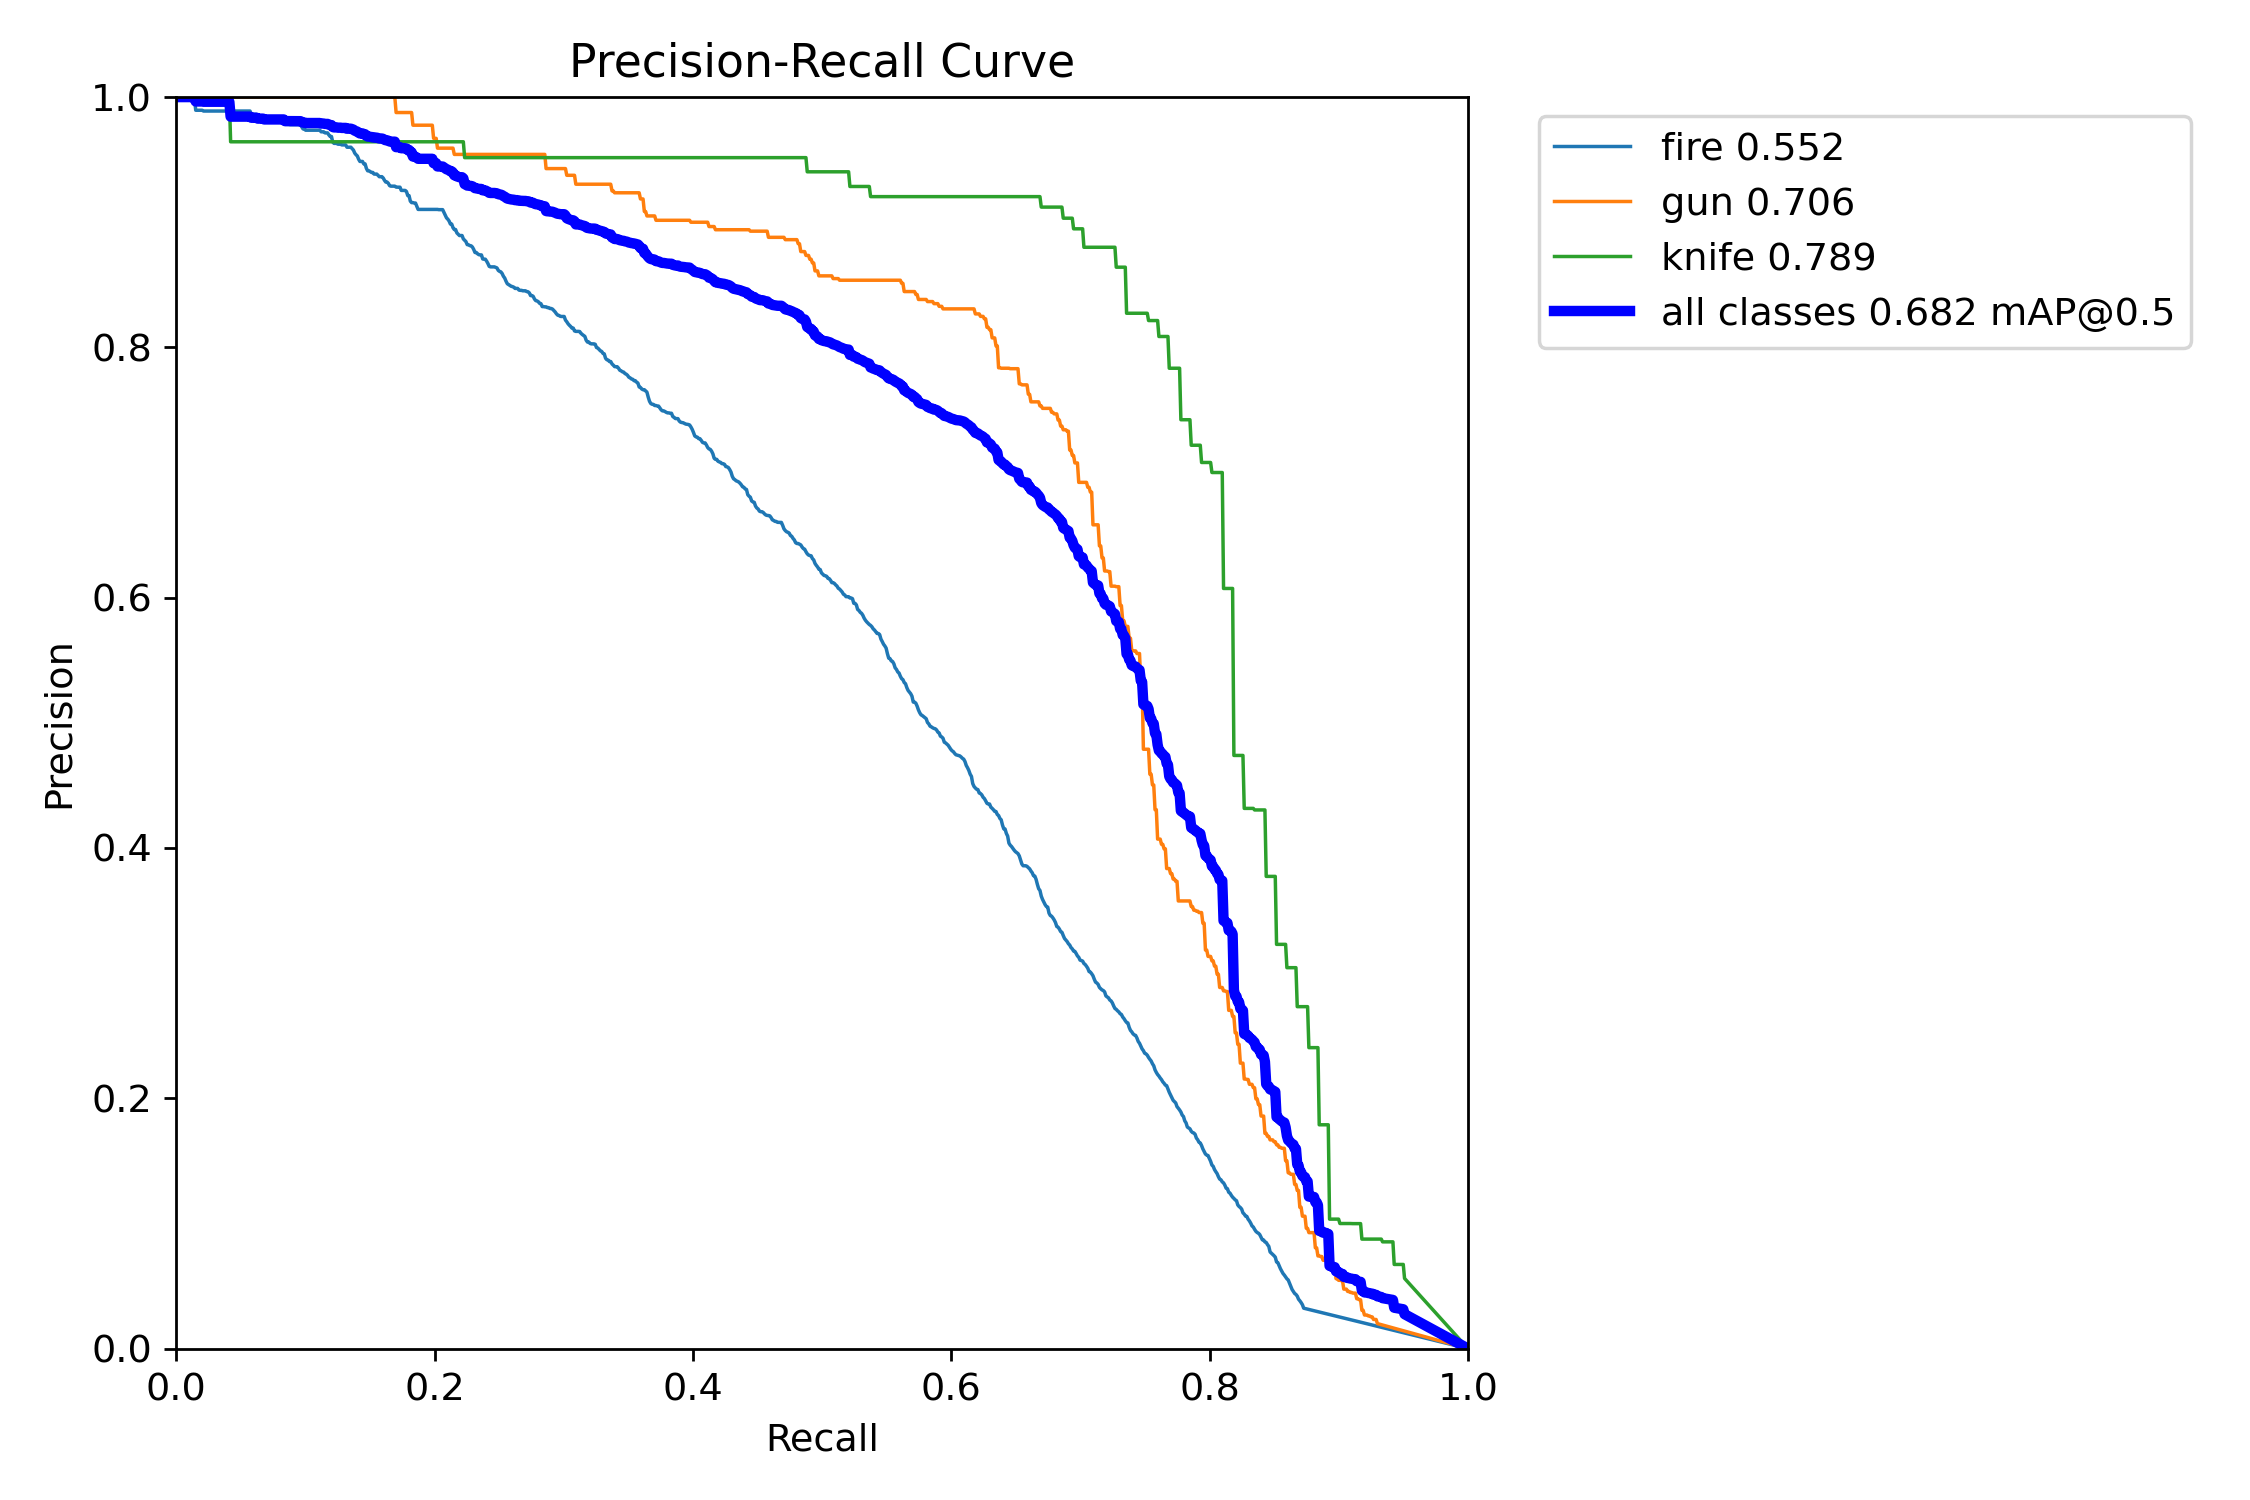

\n📊 F1 Curve:


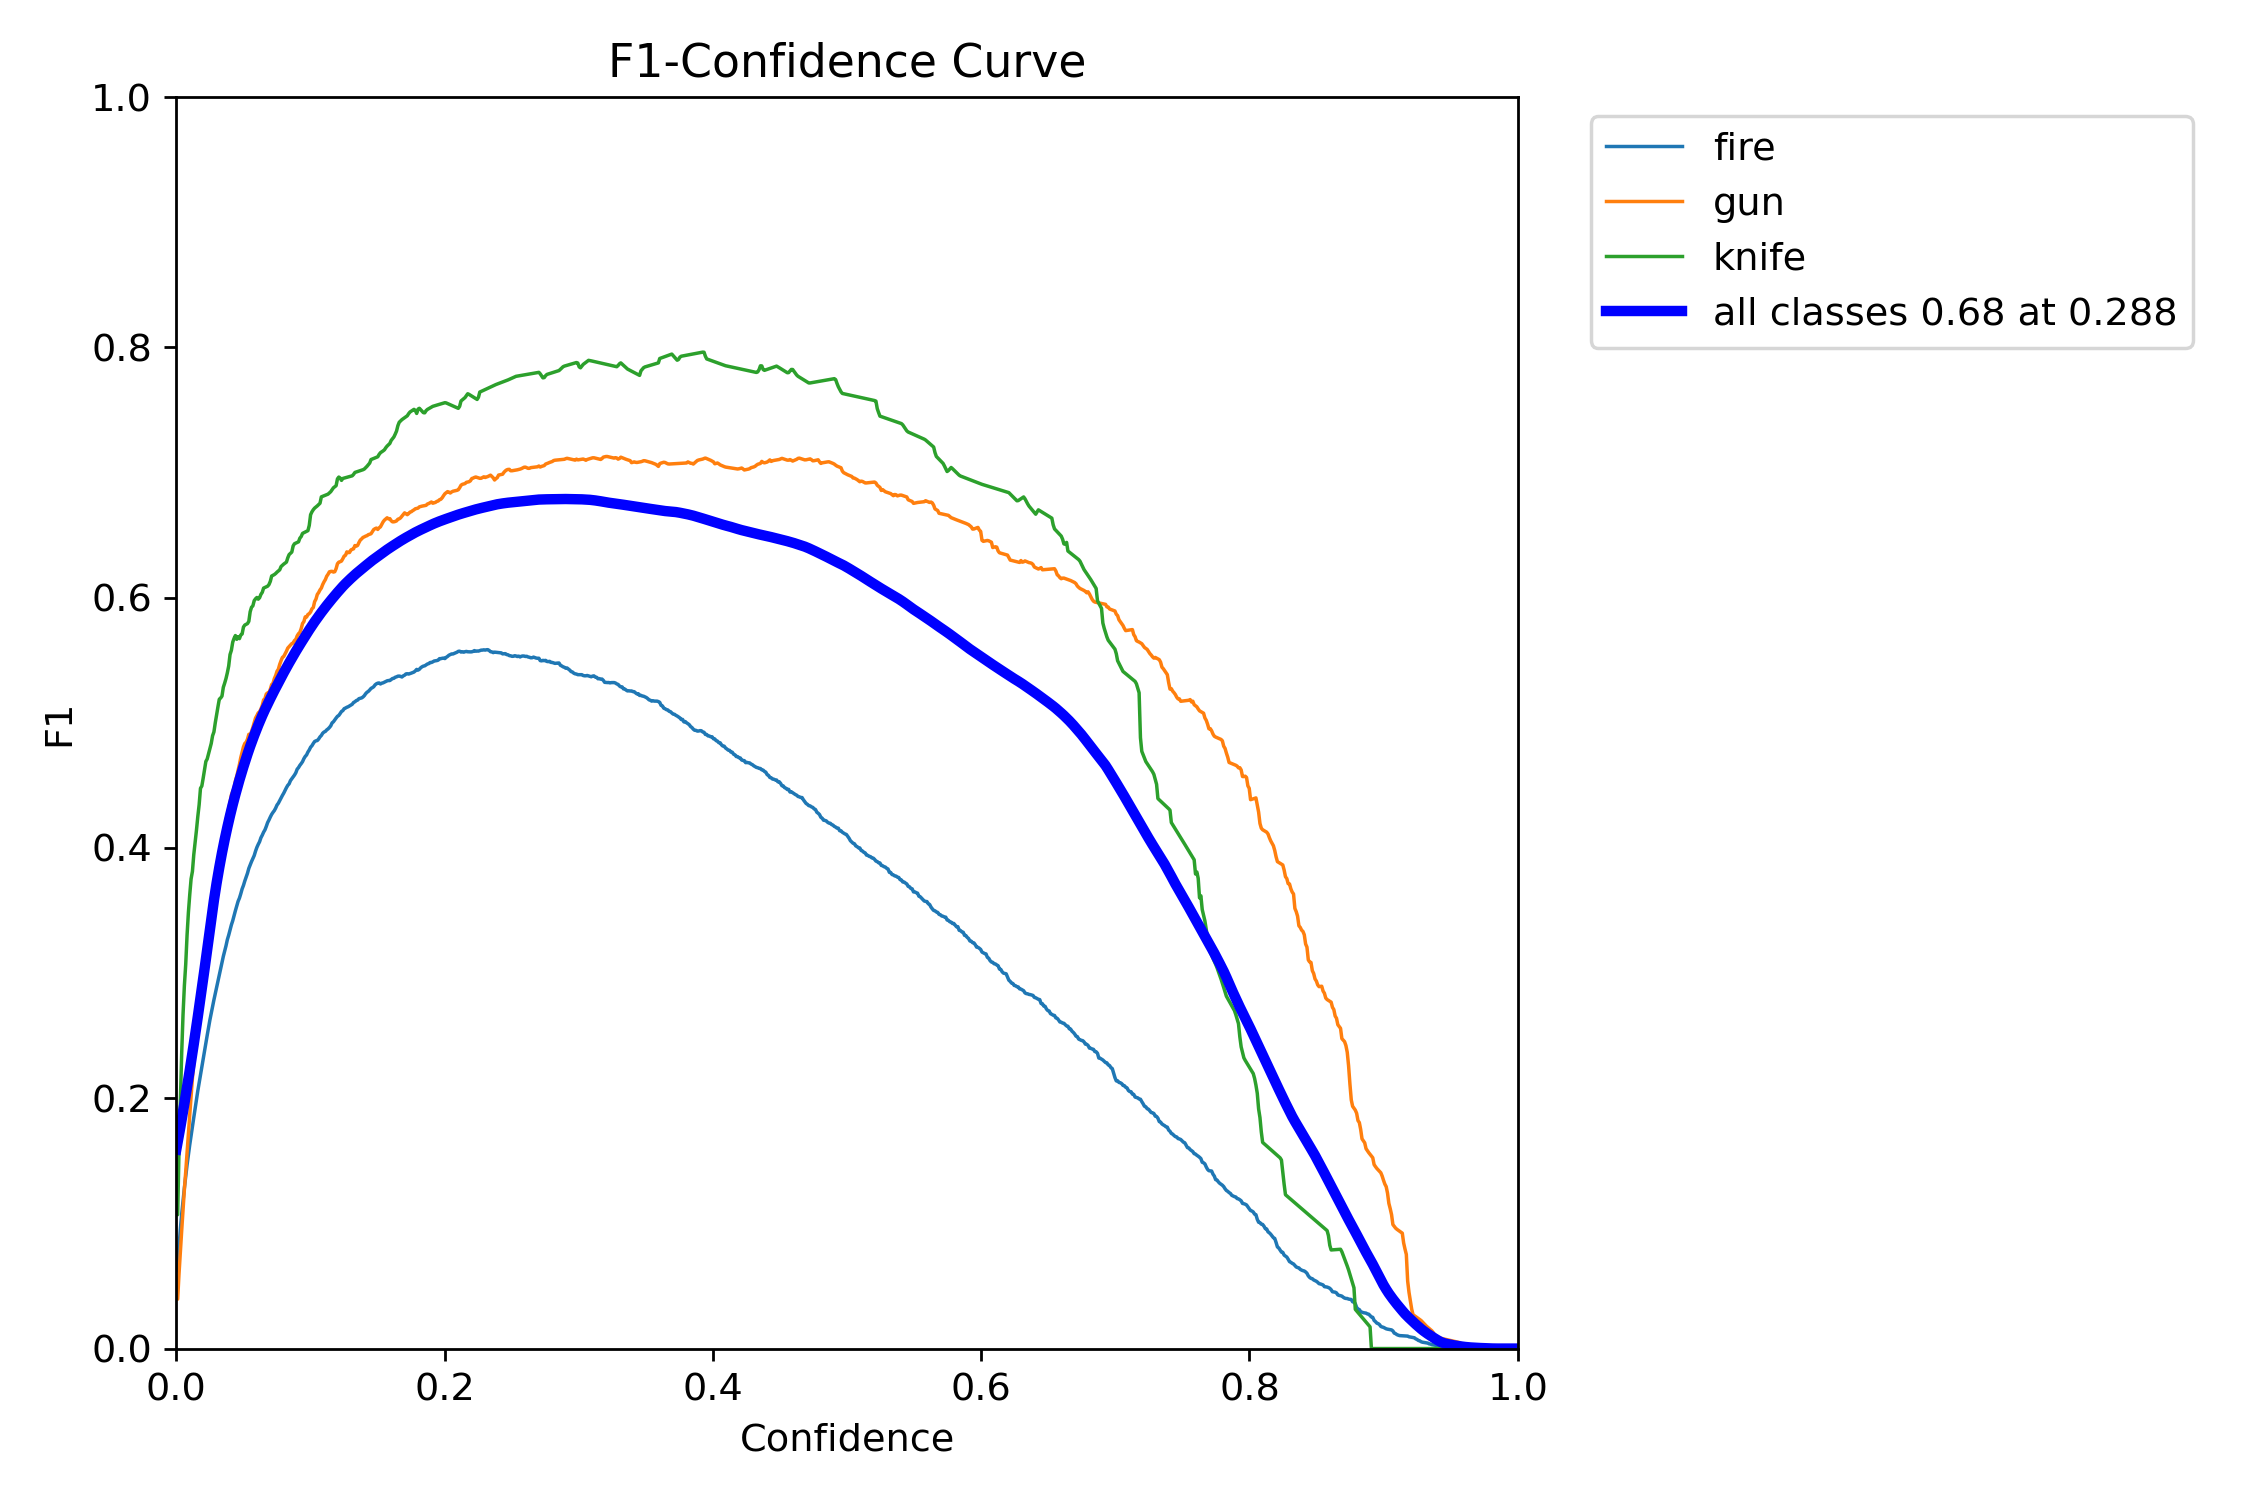

\n🔍 Val Batch0 Pred.Jpg:


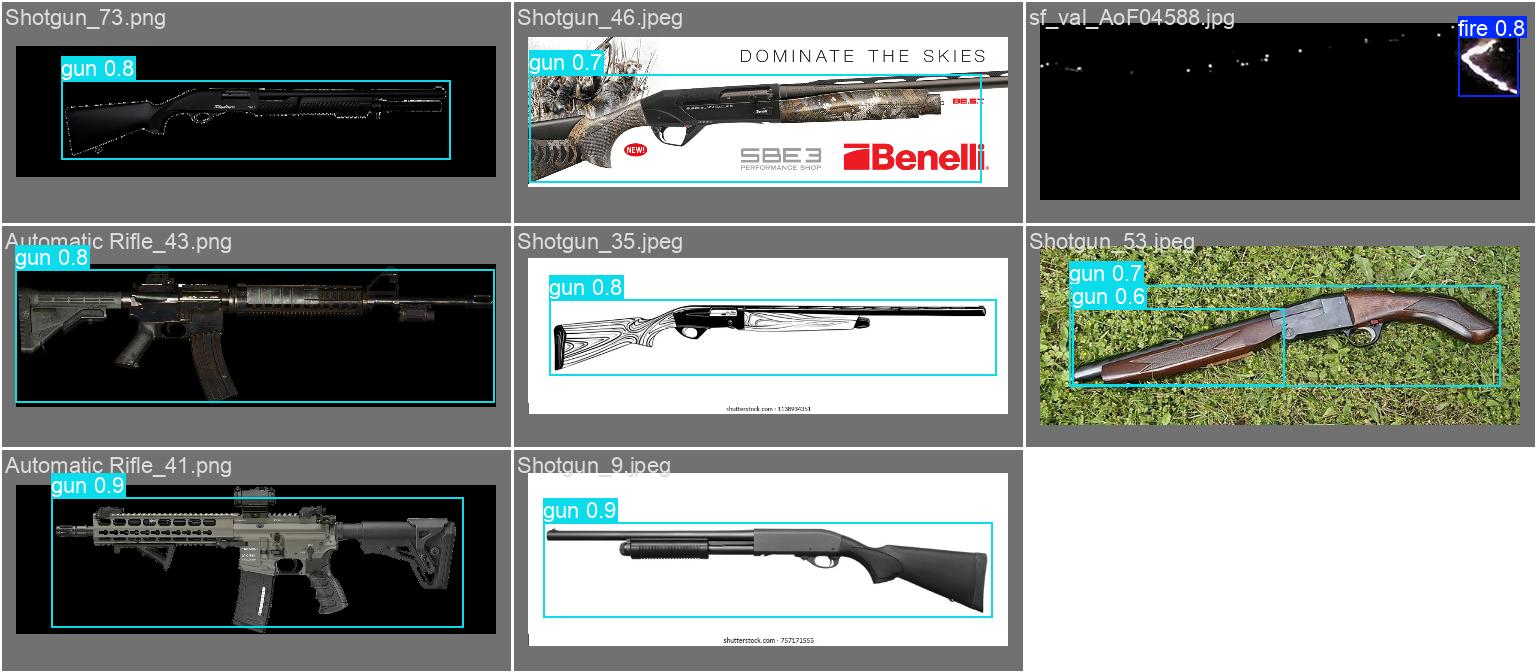

\n🔍 Val Batch2 Labels.Jpg:


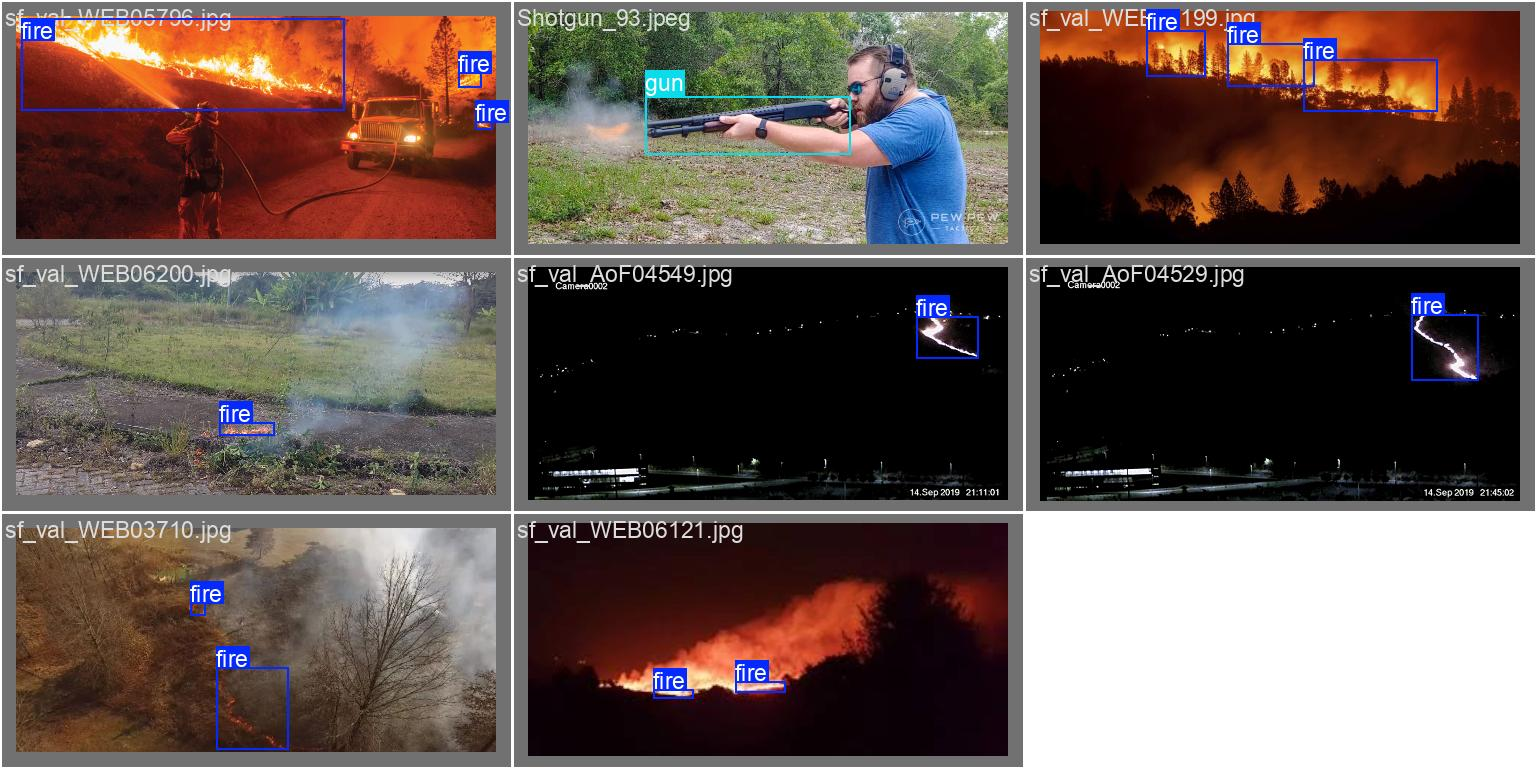

\n🎯 Final Training Metrics:


In [32]:
# Display training results
def display_training_results():
    """Display training results including plots and metrics"""
    print("📈 Displaying training results...")
    
    # Find the latest training run directory
    runs_dir = f"{HOME}/runs/detect"
    if os.path.exists(runs_dir):
        train_dirs = [d for d in os.listdir(runs_dir) if d.startswith('train')]
        if train_dirs:
            # Get the latest training directory
            latest_train_dir = sorted(train_dirs)[-1]
            train_results_dir = f"{runs_dir}/{latest_train_dir}"
            
            print(f"📁 Results directory: {train_results_dir}")
            
            # List of result images to display
            result_images = [
                'results.png',
                'confusion_matrix.png', 
                'P_curve.png',
                'R_curve.png',
                'PR_curve.png',
                'F1_curve.png'
            ]
            
            # Display each result image
            for img_name in result_images:
                img_path = f"{train_results_dir}/{img_name}"
                if os.path.exists(img_path):
                    print(f"\\n📊 {img_name.replace('_', ' ').replace('.png', '').title()}:")
                    display(IPImage(filename=img_path, width=800))
                else:
                    print(f"⚠️ {img_name} not found")
            
            # Display validation batch predictions if available
            val_batch_files = [f for f in os.listdir(train_results_dir) if f.startswith('val_batch') and f.endswith('.jpg')]
            for val_batch in val_batch_files[:2]:  # Show first 2 validation batches
                val_batch_path = f"{train_results_dir}/{val_batch}"
                print(f"\\n🔍 {val_batch.replace('_', ' ').title()}:")
                display(IPImage(filename=val_batch_path, width=800))
            
            # Read and display final metrics if CSV exists
            results_csv_path = f"{train_results_dir}/results.csv"
            if os.path.exists(results_csv_path):
                try:
                    results_df = pd.read_csv(results_csv_path)
                    final_epoch = results_df.iloc[-1]
                    
                    print("\\n🎯 Final Training Metrics:")
                    print("=" * 50)
                    metrics_to_show = [
                        ('train/box_loss', 'Training Box Loss'),
                        ('train/cls_loss', 'Training Class Loss'), 
                        ('train/dfl_loss', 'Training DFL Loss'),
                        ('val/box_loss', 'Validation Box Loss'),
                        ('val/cls_loss', 'Validation Class Loss'),
                        ('val/dfl_loss', 'Validation DFL Loss'),
                        ('metrics/precision(B)', 'Precision'),
                        ('metrics/recall(B)', 'Recall'),
                        ('metrics/mAP50(B)', 'mAP@0.5'),
                        ('metrics/mAP50-95(B)', 'mAP@0.5:0.95')
                    ]
                    
                    for metric_key, metric_name in metrics_to_show:
                        if metric_key in results_df.columns:
                            value = final_epoch[metric_key]
                            print(f"{metric_name:<25}: {value:.4f}")
                
                except Exception as e:
                    print(f"Error reading results CSV: {str(e)}")
            
            return train_results_dir
        else:
            print("❌ No training results found")
            return None
    else:
        print("❌ No runs directory found")
        return None

results_dir = display_training_results()

## ✅ 9. Model Validation

Validate the trained model on the validation dataset and analyze performance metrics.

In [33]:
# Validate the trained model
def validate_model():
    """Validate the trained model and display comprehensive metrics"""
    print("🔍 Validating trained model...")
    
    # Find the best model weights
    if results_dir:
        best_model_path = f"{results_dir}/weights/best.pt"
        if os.path.exists(best_model_path):
            print(f"📁 Loading best model from: {best_model_path}")
            
            # Load the trained model
            trained_model = YOLO(best_model_path)
            
            # Run validation
            try:
                val_results = trained_model.val(data=dataset_yaml_path, split='val', save_json=True)
                
                print("\\n🎯 Validation Metrics:")
                print("=" * 50)
                
                # Display key metrics
                metrics = {
                    'mAP@0.5': val_results.box.map50,
                    'mAP@0.5:0.95': val_results.box.map,
                    'mAP@0.75': val_results.box.map75,
                    'Precision': val_results.box.p.mean() if hasattr(val_results.box, 'p') else 'N/A',
                    'Recall': val_results.box.r.mean() if hasattr(val_results.box, 'r') else 'N/A',
                    'F1-Score': val_results.box.f1.mean() if hasattr(val_results.box, 'f1') else 'N/A'
                }
                
                for metric_name, value in metrics.items():
                    if isinstance(value, (int, float)):
                        print(f"{metric_name:<15}: {value:.4f}")
                    else:
                        print(f"{metric_name:<15}: {value}")
                
                # Class-wise metrics if available
                if hasattr(val_results.box, 'maps') and val_results.box.maps is not None:
                    print("\\n📊 Class-wise mAP@0.5:0.95:")
                    class_names = ['Fire', 'Gun', 'Knife']
                    for idx, (class_name, map_value) in enumerate(zip(class_names, val_results.box.maps)):
                        print(f"   {class_name:<10}: {map_value:.4f}")
                
                return trained_model, val_results
                
            except Exception as e:
                print(f"❌ Validation failed: {str(e)}")
                return None, None
        else:
            print("❌ Best model weights not found")
            return None, None
    else:
        print("❌ No training results directory found")
        return None, None

trained_model, validation_results = validate_model()

🔍 Validating trained model...
📁 Loading best model from: /kaggle/working/runs/detect/train2/weights/best.pt
Ultralytics 8.3.0 🚀 Python-3.11.13 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /kaggle/working/merged_dataset/val/labels.cache... 2229 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2229/2229 [00:00<?, ?it/s]

val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07535.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07536.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07539.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /kaggle/working/merged_dataset/val/images/sf_val_WEB07542.jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 140/140 [00:17<00:00,  8.23it/s]


                   all       2229       5163      0.727      0.642      0.682      0.422
                  fire       1779       4605      0.657       0.47      0.552      0.302
                   gun        333        437      0.731      0.689      0.706      0.499
                 knife        120        121      0.793      0.769      0.789      0.465


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.1ms preprocess, 2.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Saving runs/detect/val2/predictions.json...
Results saved to runs/detect/val2
\n🎯 Validation Metrics:
mAP@0.5        : 0.6825
mAP@0.5:0.95   : 0.4218
mAP@0.75       : 0.4433
Precision      : 0.7271
Recall         : 0.6424
F1-Score       : 0.6793
\n📊 Class-wise mAP@0.5:0.95:
   Fire      : 0.3017
   Gun       : 0.4992
   Knife     : 0.4646


## 🔮 10. Test Dataset Inference

Run inference on test images and visualize predictions with confidence scores.

In [ ]:
# Test dataset inference
def run_inference_on_test_set():
    """Run inference on test dataset and visualize results"""
    print("🔮 Running inference on test dataset...")
    
    if trained_model is None:
        print("❌ No trained model available. Please ensure training completed successfully.")
        return
    
    test_images_dir = f"{MERGED_DATASET_PATH}/test/images"
    
    if not os.path.exists(test_images_dir):
        print("❌ Test images directory not found")
        return
    
    # Get test images
    test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not test_images:
        print("❌ No test images found")
        return
    
    print(f"🖼️ Found {len(test_images)} test images")
    
    # Run inference on test images
    try:
        results = trained_model.predict(
            source=test_images_dir,
            conf=0.25,  # Confidence threshold
            iou=0.45,   # IoU threshold for NMS
            save=True,  # Save predictions
            save_txt=True,  # Save predictions in YOLO format
            save_conf=True,  # Save confidence scores
            show_labels=True,
            show_conf=True,
            line_width=2
        )
        
        print("✅ Inference completed successfully!")
        
        # Display some prediction results
        visualize_predictions(results[:12])  # Show first 12 predictions
        
        return results
        
    except Exception as e:
        print(f"❌ Inference failed: {str(e)}")
        return None

def visualize_predictions(results, max_images=12):
    """Visualize prediction results"""
    if not results:
        print("No predictions to visualize")
        return
    
    print(f"🎯 Visualizing first {min(len(results), max_images)} predictions...")
    
    # Setup plot
    rows = int(np.ceil(np.sqrt(max_images)))
    cols = int(np.ceil(max_images / rows))
    
    plt.figure(figsize=(20, 20))
    
    class_names = ['Fire', 'Gun', 'Knife']
    class_colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]  # Red, Green, Blue
    
    for idx, result in enumerate(results[:max_images]):
        plt.subplot(rows, cols, idx + 1)
        
        # Load original image
        img_path = result.path
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Draw predictions
        if result.boxes is not None and len(result.boxes) > 0:
            boxes = result.boxes.xyxy.cpu().numpy()  # Bounding boxes
            confs = result.boxes.conf.cpu().numpy()  # Confidence scores
            classes = result.boxes.cls.cpu().numpy().astype(int)  # Class indices
            
            for box, conf, cls in zip(boxes, confs, classes):
                if cls < len(class_names):  # Valid class
                    x1, y1, x2, y2 = box.astype(int)
                    
                    # Draw bounding box
                    color = class_colors[cls]
                    cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
                    
                    # Add label with confidence
                    label = f"{class_names[cls]}: {conf:.2f}"
                    label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
                    cv2.rectangle(image, (x1, y1 - label_size[1] - 10), 
                                (x1 + label_size[0], y1), color, -1)
                    cv2.putText(image, label, (x1, y1 - 5), 
                              cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        plt.imshow(image)
        plt.title(f'Test Image {idx + 1}', fontsize=12)
        plt.axis('off')
    
    plt.suptitle('Model Predictions on Test Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run inference
inference_results = run_inference_on_test_set()

🔮 Running inference on test dataset...
🖼️ Found 1878 test images


WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1878 /kaggle/working/merged_dataset/test/images/cctv_test_-Video-00-00-04-000-_jpg.rf.b839cc55a75f448e32ea250ee7fea072.jpg: 480x480 (no detections), 7.6ms
image 2/1878 /kaggle/working/merged_dataset/test/images/cctv_test_-Video-00-00-05-600-_jpg.rf.4ee7d66ff58b026d3b71c69221021c02.jpg: 480x480 1 gun, 7.7ms
image 3/1878 /kaggle/working/merged_dataset/test/images/cctv_test_-Video-00

In [36]:
import shutil

# Zip the folders you want
shutil.make_archive('/kaggle/working/predict2', 'zip', '/kaggle/working/runs/detect/predict2')
shutil.make_archive('/kaggle/working/train2', 'zip', '/kaggle/working/runs/detect/train2')
shutil.make_archive('/kaggle/working/val2', 'zip', '/kaggle/working/runs/detect/val2')
from IPython.display import FileLink, display

display(FileLink('/kaggle/working/predict2.zip'))
display(FileLink('/kaggle/working/train2.zip'))
display(FileLink('/kaggle/working/val2.zip'))


/kaggle/working/predict2.zip

/kaggle/working/train2.zip

/kaggle/working/val2.zip

In [ ]:
print(5)

In [ ]:
!zip -r /kaggle/working/merged_dataset.zip /kaggle/working/merged_dataset/

  adding: kaggle/working/merged_dataset/ (stored 0%)
  adding: kaggle/working/merged_dataset/test/ (stored 0%)
  adding: kaggle/working/merged_dataset/test/images/ (stored 0%)
  adding: kaggle/working/merged_dataset/test/images/sf_test_WEB10891.jpg (deflated 7%)
  adding: kaggle/working/merged_dataset/test/images/sf_test_WEB11143.jpg (deflated 0%)
  adding: kaggle/working/merged_dataset/test/images/fire-2146-_png.rf.230267e00e11655b76d50ae3d322ce63.jpg (deflated 1%)
  adding: kaggle/working/merged_dataset/test/images/sf_test_WEB10831.jpg (deflated 2%)
  adding: kaggle/working/merged_dataset/test/images/sf_test_AoF07905.jpg (deflated 18%)
  adding: kaggle/working/merged_dataset/test/images/fire-2818-_png.rf.12ca75137eeb031e7737a838cfa5e1e8.jpg (deflated 1%)
  adding: kaggle/working/merged_dataset/test/images/sf_test_WEB10772.jpg (deflated 3%)
  adding: kaggle/working/merged_dataset/test/images/sf_test_WEB10808.jpg (deflated 2%)
  adding: kaggle/working/merged_dataset/test/images/cctv_te

In [37]:
!zip -r /kaggle/working/detect_results.zip /kaggle/working/runs/detect/


  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/sf_test_WEB10891.jpg (deflated 7%)
  adding: kaggle/working/runs/detect/predict/sf_test_WEB11143.jpg (deflated 0%)
  adding: kaggle/working/runs/detect/predict/fire-2146-_png.rf.230267e00e11655b76d50ae3d322ce63.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/sf_test_WEB10831.jpg (deflated 1%)
  adding: kaggle/working/runs/detect/predict/sf_test_AoF07905.jpg (deflated 18%)
  adding: kaggle/working/runs/detect/predict/fire-2818-_png.rf.12ca75137eeb031e7737a838cfa5e1e8.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/sf_test_WEB10772.jpg (deflated 3%)
  adding: kaggle/working/runs/detect/predict/sf_test_WEB10808.jpg (deflated 2%)
  adding: kaggle/working/runs/detect/predict/cctv_test_20221013_191958_jpg.rf.a4edc1a08d679c7994ef34c28eb37f69.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/cctv_test

## 📋 Summary and Conclusion

**🎉 Multi-Object Detection Model Training Complete!**

### 📊 Project Summary

We successfully created and trained a unified YOLOv11 model for detecting three critical objects:

1. **🔥 Fire Detection** - From FlameVision and Smoke & Fire datasets
2. **🔫 Gun Detection** - Mapped from multiple weapon types (rifles, handguns, shotguns, etc.)
3. **🗡️ Knife Detection** - Including knives and swords from weapon datasets

### 🔄 Dataset Integration Process

- **FlameVision Dataset**: Converted XML annotations to YOLO format for fire detection
- **Weapon Detection Dataset**: Mapped 9 weapon classes to Gun/Knife categories  
- **CCTV Guns & Knives**: Integrated existing YOLO format data
- **Smoke & Fire Dataset**: Extracted fire detections, ignored smoke class

### 🎯 Final Model Capabilities

The trained YOLOv11 model can now detect:
- **Fire (Class 0)**: Flames and fire incidents
- **Gun (Class 1)**: Various firearms and weapons
- **Knife (Class 2)**: Knives, blades, and sharp weapons

### 🚀 Next Steps

1. **Model Optimization**: Fine-tune hyperparameters for better performance
2. **Data Augmentation**: Add more diverse samples for improved generalization
3. **Real-time Deployment**: Integrate model into surveillance or safety systems
4. **Performance Monitoring**: Continuously evaluate and improve model accuracy

### 💾 Model Export

The trained model weights are saved as:
- **Best weights**: `runs/detect/train/weights/best.pt`
- **Last weights**: `runs/detect/train/weights/last.pt`

---

**🔬 This notebook demonstrates a complete end-to-end pipeline for multi-dataset integration and object detection training using YOLOv11!**